# **Hotel Booking Cancellation**

**Dataset:** `hotel_bookings_dataset.csv` (119.390 baris, 32 kolom)

**Streamlit:** https://hotel-cancellation-pre.streamlit.app/

## Daftar Isi
1. [Business Understanding](#1.-Business-Understanding)
2. [Data Understanding](#2.-Data-Understanding)
3. [Data Cleaning](#3.-Data-Cleaning)
4. [Univariate Analysis](#4.-Univariate-Analysis)
5. [Bivariate Analysis](#5.-Bivariate-Analysis)
6. [Multivariate Analysis & Korelasi/VIF](#6.-Multivariate-Analysis)
7. [5 Pertanyaan Bisnis EDA](#7.-5-Pertanyaan-Bisnis-EDA)
8. [Data Preprocessing untuk Modeling](#8.-Data-Preprocessing)
9. [Model Benchmarking](#9.-Model-Benchmarking)
10. [Top 3 Model, Hyperparameter Tuning & Cross Validation](#10.-Top-3-Model)
11. [After Modeling: Threshold, Feature Importance, Cost-Benefit](#11.-After-Modeling)
12. [Simpan Model Final & Fungsi Deteksi Booking Berisiko](#12.-Simpan-Model)
13. [Kesimpulan & Rekomendasi Bisnis](#13.-Kesimpulan)


## 1. Business Understanding

### Latar Belakang
Pembatalan reservasi merupakan tantangan umum dalam industri perhotelan karena dapat menimbulkan kerugian finansial dan mengganggu perencanaan operasional. Pembatalan mendadak menyebabkan hotel kehilangan peluang untuk menjual kembali kamar, terutama pada periode dengan permintaan tinggi.

Kemudahan pemesanan melalui platform daring (Online Travel Agency/OTA) juga membuat pelanggan lebih mudah membatalkan atau mengubah reservasi. Oleh karena itu, kemampuan memprediksi risiko pembatalan sejak awal pemesanan menjadi penting bagi manajemen hotel.

Dengan memanfaatkan data historis seperti segmen pasar, jenis deposit, histori pembatalan, dan permintaan khusus, machine learning dapat digunakan untuk mengidentifikasi reservasi yang berisiko dibatalkan. Hasil prediksi dapat mendukung strategi mitigasi, seperti pengelolaan overbooking, penyesuaian kebijakan deposit, dan optimalisasi tingkat hunian.

Sebelum membangun model, perlu dipahami faktor yang memengaruhi pembatalan. Pembatalan atau ketidakhadiran tamu dapat disebabkan oleh berbagai kondisi tak terduga, seperti sakit, kecelakaan, konflik jadwal, kewajiban keluarga, dan bencana alam. Selain faktor tersebut, karakteristik saluran pemesanan juga dapat memengaruhi tingkat pembatalan.

### Permasalahan Bisnis
Bagaimana hotel dapat memanfaatkan data historis reservasi untuk **memprediksi kemungkinan pembatalan sejak awal proses booking**, sehingga tindakan mitigasi (kebijakan deposit, komunikasi retensi, atau *controlled overbooking*) dapat dilakukan lebih tepat sasaran dan pada akhirnya **mengurangi jumlah kamar kosong**?

### Goals
Berdasarkan permasalahan tersebut, perusahaan ingin mengetahui pembatalan reservasi sejak awal proses pemesanan dalam rangka mengambil tindakan preventif berdasarkan resiko pembetalan, sehingga dapat memfokuskan pada alokasi operasional terhadap pemesanan yang memiliki resiko rendah.

Selain itu, perusahaan juga ingin mengetahui faktor-faktor yang mempengaruhi pemesan membatalkan reservasinya, sehingga perusahaan dapat membuat plan yang lebih baik terhadap pembatalan pemesanan.



## 2. Data Understanding

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option('display.max_columns', 40)

df = pd.read_csv('hotel_bookings_dataset.csv')
print("Jumlah baris:", df.shape[0], "| Jumlah kolom:", df.shape[1])
df.head()

Jumlah baris: 119390 | Jumlah kolom: 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


**Deskripsi Fitur Utama** (32 kolom penuh)

| Fitur | Deskripsi |
| --- | --- |
| `hotel` | Jenis hotel (City Hotel / Resort Hotel) |
| `lead_time` | Jumlah hari antara tanggal pemesanan dan tanggal kedatangan |
| `arrival_date_year/month/week_number/day_of_month` | Tanggal kedatangan tamu |
| `stays_in_weekend_nights`, `stays_in_week_nights` | Lama menginap (akhir pekan / hari kerja) |
| `adults`, `children`, `babies` | Jumlah tamu |
| `meal` | Paket makan yang dipesan |
| `country` | Negara asal tamu |
| `market_segment`, `distribution_channel` | Segmen pasar & channel distribusi |
| `is_repeated_guest` | Apakah tamu pernah menginap sebelumnya |
| `previous_cancellations`, `previous_bookings_not_canceled` | Riwayat pembatalan tamu |
| `reserved_room_type`, `assigned_room_type` | Tipe kamar yang dipesan vs yang benar-benar dialokasikan |
| `booking_changes` | Jumlah perubahan pada reservasi |
| `deposit_type` | Jenis deposit (No Deposit / Non Refund / Refundable) |
| `agent`, `company` | Kode ID agen/perusahaan pemesan |
| `days_in_waiting_list` | Lama hari di waiting list |
| `customer_type` | Tipe pemesan |
| `adr` | *Average Daily Rate* (harga kamar per malam) |
| `required_car_parking_spaces` | Jumlah lahan parkir yang diminta |
| `total_of_special_requests` | Jumlah permintaan khusus |
| `is_canceled` | **Target** — 1 = dibatalkan, 0 = tidak dibatalkan |
| `reservation_status`, `reservation_status_date` | Status akhir reservasi & tanggalnya — **berisiko *data leakage*** |


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [3]:
target_count = df['is_canceled'].value_counts().reset_index()
target_count.columns = ['is_canceled', 'count']
target_count['Percentage (%)'] = target_count['count'] / target_count['count'].sum() * 100
target_count

,is_canceled,count,Percentage (%)
0,0,75166,62.958372
1,1,44224,37.041628


**Insight awal:** Cancellation rate pada data mentah adalah sekitar **37%** (44.224 dari 119.390 booking), konsisten dengan permasalahan bisnis perusahaan yakni tingginya cancellation rate. Dengan jumlah booking 119.390 dan memiliki 32 kolom.

## 3. Data Cleaning

Tahapan: cek & hapus duplikat → tangani *missing value* → cek & tangani anomali → buang fitur yang berisiko *data leakage* → konfirmasi ulang distribusi target.

In [4]:
df_unique = []

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

for i in df.columns:
    unique_count = df[i].nunique()
    unique_values = df[i].unique()
    data_type = df[i].dtype
    df_unique.append({
        "Column Name": i,
        "Number of Unique": unique_count,
        "Data Type": data_type,
        "Unique Sample": unique_values
    })

df_unique = pd.DataFrame(df_unique)
display(df_unique)

,Column Name,Number of Unique,Data Type,Unique Sample
0,hotel,2,object,"[Resort Hotel, City Hotel]"
1,is_canceled,2,int64,"[0, 1]"
2,lead_time,479,int64,"[342, 737, 7, 13, 14, 0, 9, 85, 75, 23, 35, 68, 18, 37, 12, 72, 127, 78, 48, 60, 77, 99, 118, 95, 96, 69, 45, 40, 15, 36, 43, 70, 16, 107, 47, 113, 90, 50, 93, 76, 3, 1, 10, 5, 17, 51, 71, 63, 62, 101, 2, 81, 368, 364, 324, 79, 21, 109, 102, 4, 98, 92, 26, 73, 115, 86, 52, 29, 30, 33, 32, 8, 100, 44, 80, 97, 64, 39, 34, 27, 82, 94, 110, 111, 84, 66, 104, 28, 258, 112, 65, 67, 55, 88, 54, 292, 83, 105, 280, 394, ...]"
3,arrival_date_year,3,int64,"[2015, 2016, 2017]"
4,arrival_date_month,12,object,"[July, August, September, October, November, December, January, February, March, April, May, June]"
5,arrival_date_week_number,53,int64,"[27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]"
6,arrival_date_day_of_month,31,int64,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]"
7,stays_in_weekend_nights,17,int64,"[0, 1, 2, 4, 3, 6, 13, 8, 5, 7, 12, 9, 16, 18, 19, 10, 14]"
8,stays_in_week_nights,35,int64,"[0, 1, 2, 3, 4, 5, 10, 11, 8, 6, 7, 15, 9, 12, 33, 20, 14, 16, 21, 13, 30, 19, 24, 40, 22, 42, 50, 25, 17, 32, 26, 18, 34, 35, 41]"
9,adults,14,int64,"[2, 1, 3, 4, 40, 26, 50, 27, 55, 0, 20, 6, 5, 10]"


### 3.1 Duplicate Data

In [5]:
n_duplicates = df.duplicated().sum()
print(f"Jumlah baris duplikat: {n_duplicates} dari total {df.shape[0]} baris "
      f"({n_duplicates/df.shape[0]*100:.1f}%)")

Jumlah baris duplikat: 31994 dari total 119390 baris (26.8%)


**Catatan:** Terdapat **31.994** duplikasi data meskipun jumlahnya sangat banyak, hal ini sangat berbahaya untuk model machine learning karena dapat terjadi data leakage, overfitting dan bias. maka dari itu data duplikasi ini dapat di drop

In [6]:
df = df.drop_duplicates().reset_index(drop=True)
print("Jumlah baris setelah drop duplikat:", df.shape[0])

Jumlah baris setelah drop duplikat: 87396


### 3.2 Missing Values

In [7]:
missing = df.isna().sum()
missing = missing[missing > 0]
missing_pct = (missing / df.shape[0]) * 100
pd.DataFrame({"Jumlah Missing": missing, "Missing (%)": missing_pct}).sort_values("Missing (%)", ascending=False)

,Jumlah Missing,Missing (%)
company,82137,93.982562
agent,12193,13.951439
country,452,0.517186
children,4,0.004577


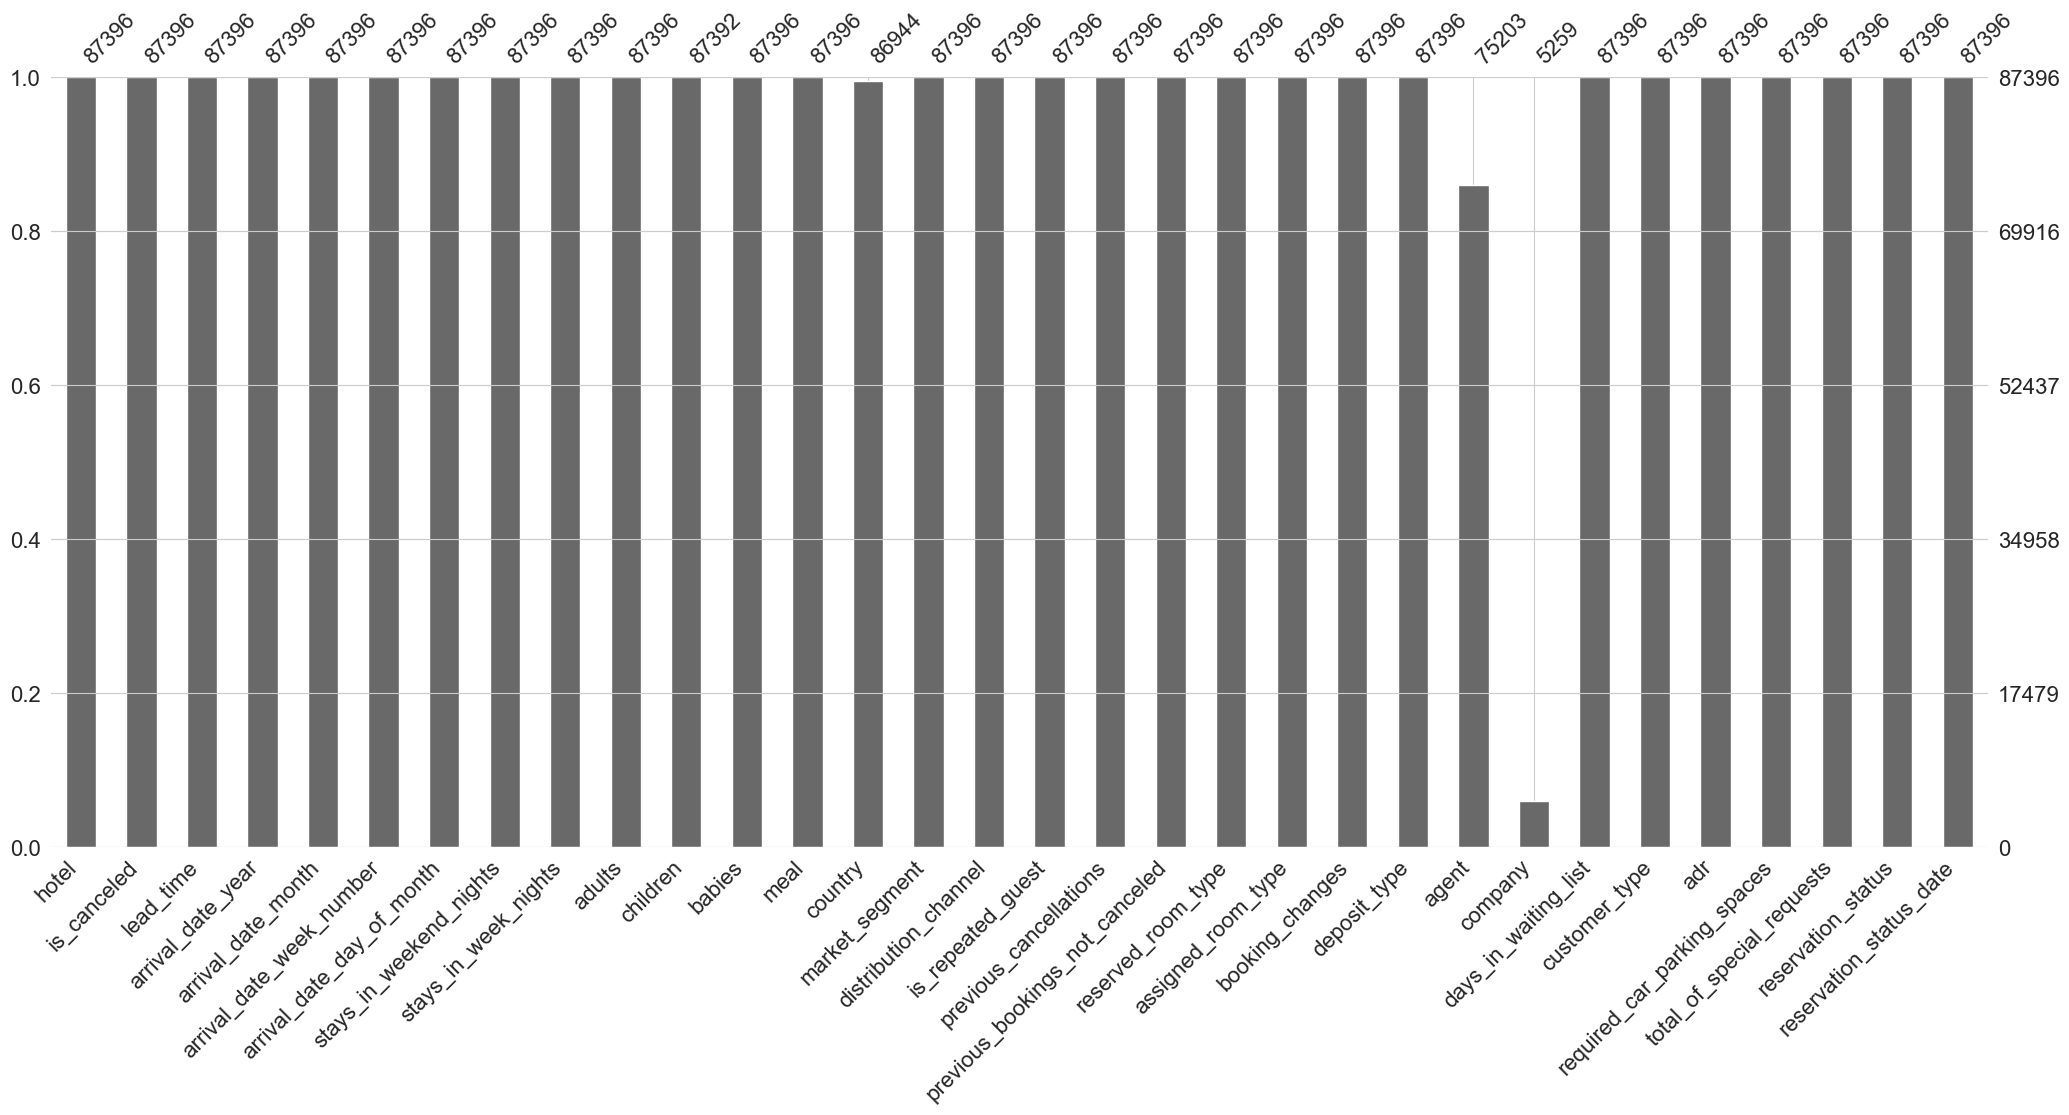

In [8]:
import missingno as msno
msno.bar(df)
plt.show()

**Insight & perlakuan:**
- `company` — hilang >90% baris → **kolom dibuang**, terlalu banyak missing untuk diandalkan.
- `agent` — hilang cukup banyak (~14%), berupa kode ID agen yang sulit diinterpretasi sebagai fitur kategorikal beramplitudo besar → **kolom dibuang** untuk menjaga model tetap sederhana dan menghindari *overfitting* pada ID.
- `country` — hilang sangat kecil (<1%) → baris dengan missing langsung **dibuang**.
- `children` — hilang hanya beberapa baris → **diisi 0** (asumsi wajar: tidak dicatat berarti tidak ada anak).

In [9]:
df['children'] = df['children'].fillna(0)
df = df.dropna(subset=['country']).reset_index(drop=True)
df = df.drop(columns=['agent', 'company'])
print("Jumlah baris setelah handling missing value:", df.shape[0])
print("Sisa missing value:", df.isna().sum().sum())

Jumlah baris setelah handling missing value: 86944
Sisa missing value: 0


In [10]:
data_loss = df.isna().sum()
loss = data_loss[data_loss>0]
percentage = (data_loss/df.shape[0])*100
missing = pd.DataFrame({"Jumlah Missing": loss, "Missing (%)": percentage})
missing.sort_values(by="Missing (%)", ascending=False)

,Jumlah Missing,Missing (%)
adr,NaN,0.0
adults,NaN,0.0
stays_in_weekend_nights,NaN,0.0
stays_in_week_nights,NaN,0.0
reserved_room_type,NaN,0.0
reservation_status_date,NaN,0.0
reservation_status,NaN,0.0
required_car_parking_spaces,NaN,0.0
previous_cancellations,NaN,0.0
previous_bookings_not_canceled,NaN,0.0


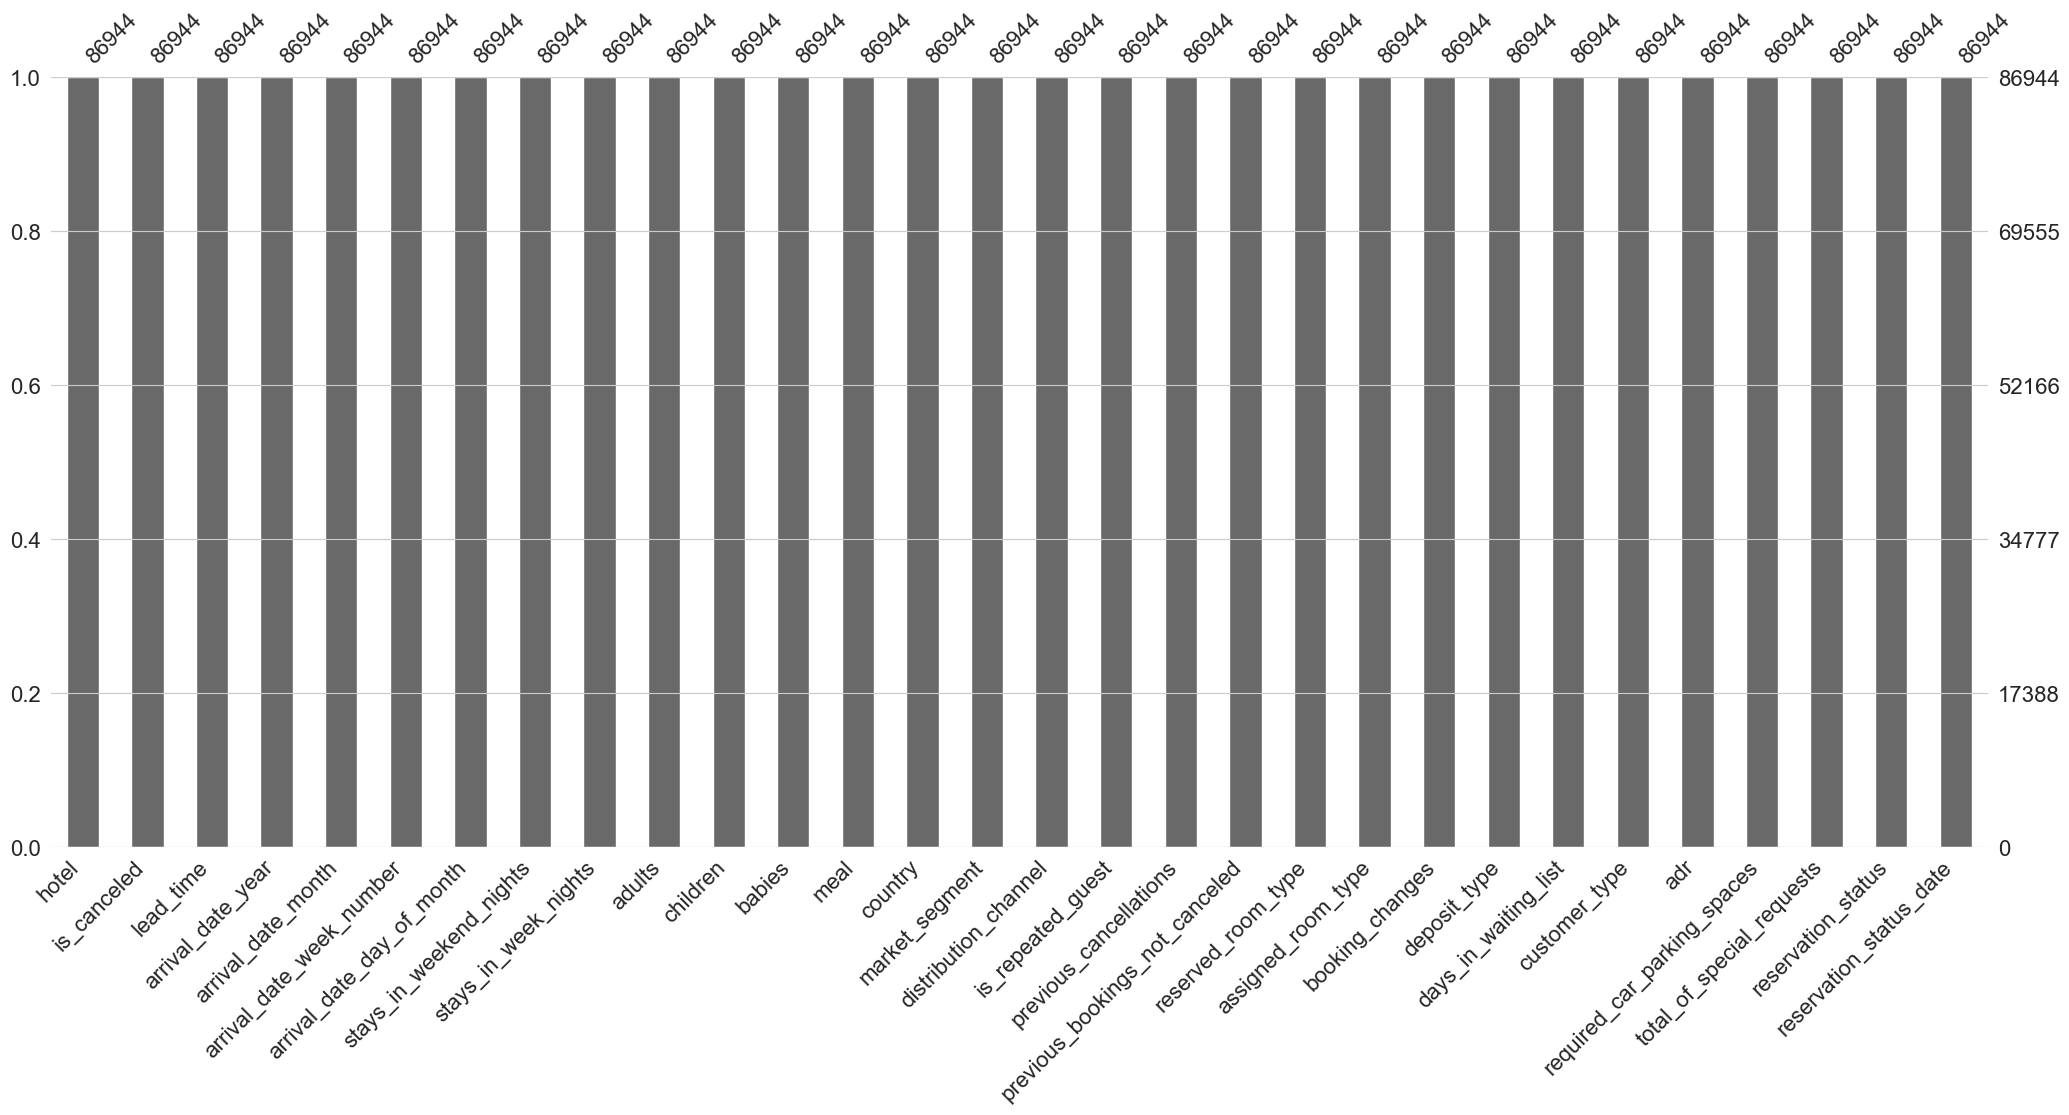

In [11]:
msno.bar(df)
plt.show()

### 3.3 Anomali Data

In [12]:
zero_guest = df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)]
print("Baris dengan 0 tamu (adults+children+babies=0):", len(zero_guest))
print("Baris dengan adr negatif:", (df['adr'] < 0).sum())
print("Baris dengan adr ekstrem (>5000):", (df['adr'] > 5000).sum())
print("Kategori 'Undefined' pada market_segment:", (df['market_segment'] == 'Undefined').sum())
print("Kategori 'Undefined' pada distribution_channel:", (df['distribution_channel'] == 'Undefined').sum())

Baris dengan 0 tamu (adults+children+babies=0): 161
Baris dengan adr negatif: 1
Baris dengan adr ekstrem (>5000): 1
Kategori 'Undefined' pada market_segment: 2
Kategori 'Undefined' pada distribution_channel: 5


**Insight:** Ditemukan beberapa anomali yang tidak masuk akal secara bisnis yakni reservasi tanpa tamu sama sekali, `adr` (harga kamar) negatif atau ekstrem tidak wajar, serta kategori `Undefined` pada segmen/channel. Semua baris ini dibuang karena jumlahnya sangat kecil relatif terhadap total data dan berpotensi berupa kesalahan input.

In [13]:
df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))].reset_index(drop=True)
df = df[(df['adr'] >= 0) & (df['adr'] < 5000)].reset_index(drop=True)
df = df[~df['market_segment'].isin(['Undefined'])].reset_index(drop=True)
df = df[~df['distribution_channel'].isin(['Undefined'])].reset_index(drop=True)
print("Jumlah baris setelah buang anomali:", df.shape[0])

Jumlah baris setelah buang anomali: 86776


### 3.4 Membuang Fitur Berisiko *Data Leakage*

Karena tujuan model adalah memprediksi pembatalan **sejak awal proses booking**, beberapa kolom harus dibuang karena nilainya baru diketahui **setelah** kejadian (pembatalan/kedatangan tamu):

| Kolom | Alasan dibuang |
| --- | --- |
| `reservation_status` | Nilainya (`Canceled`/`Check-Out`/`No-Show`) pada dasarnya **adalah target itu sendiri** dalam bentuk lain. |
| `reservation_status_date` | Tanggal status terakhir ditentukan yakni untuk booking yang batal, ini adalah tanggal pembatalan, jelas tidak diketahui di awal. |
| `assigned_room_type` | Kamar yang benar-benar dialokasikan baru diketahui mendekati/saat check-in, bukan saat booking dibuat. |
| `arrival_date_year`, `arrival_date_week_number`, `arrival_date_day_of_month` | Dibuang agar model tidak "menghafal" tahun/minggu spesifik pada data historis (risiko *overfitting* & tidak general ke periode mendatang). Informasi musiman tetap dipertahankan lewat `arrival_date_month`. |


In [14]:
leakage_cols = ['reservation_status', 'reservation_status_date', 'assigned_room_type',
                'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month']
df = df.drop(columns=leakage_cols)
print("Jumlah kolom setelah membuang fitur leakage:", df.shape[1])
df.columns.tolist()

Jumlah kolom setelah membuang fitur leakage: 24


['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'booking_changes',
 'deposit_type',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

### 3.5 Distribusi Target Setelah Cleaning

In [15]:
target_count = df['is_canceled'].value_counts().reset_index()
target_count.columns = ['is_canceled', 'count']
target_count['Percentage (%)'] = target_count['count'] / target_count['count'].sum() * 100
target_count

,is_canceled,count,Percentage (%)
0,0,62801,72.371393
1,1,23975,27.628607


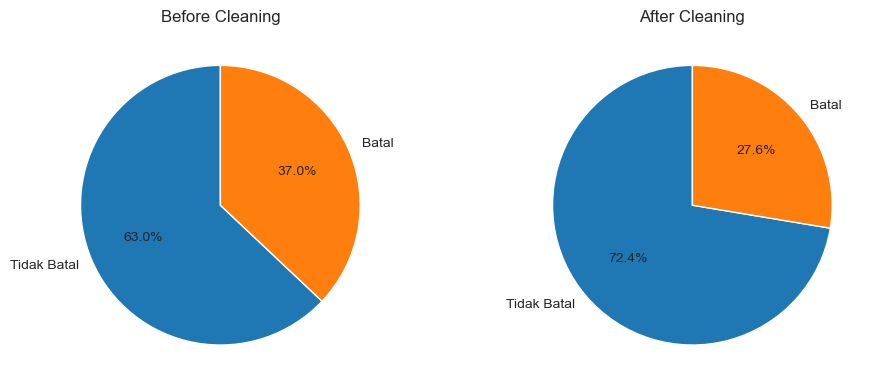

In [16]:
# Data sebelum cleaning
before = [75166, 44224]

# Data setelah cleaning
after = [62801, 23975]

labels = ['Tidak Batal', 'Batal']

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Before Cleaning
ax[0].pie(before, labels=labels, autopct='%1.1f%%', startangle=90)
ax[0].set_title('Before Cleaning')

# After Cleaning
ax[1].pie(after,labels=labels,autopct='%1.1f%%',startangle=90)
ax[1].set_title('After Cleaning')

plt.tight_layout()
plt.show()

**Insight penting:** Setelah proses cleaning (terutama pembuangan duplikat), cancellation rate bergeser dari **~37% (data mentah)** menjadi **27.6%**. Pergeseran ini murni disebabkan oleh langkah pembuangan duplikat.

## 4. Univariate Analysis

Melihat sebaran masing-masing fitur secara individual, sebelum dikaitkan dengan target.

In [17]:
num_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
            'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled',
            'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
            'total_of_special_requests']

cat_cols = ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
            'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,86776.0,80.268335,86.106455,0.0,12.00,50.00,125.0,737.0
stays_in_weekend_nights,86776.0,1.006695,1.024208,0.0,0.00,1.00,2.0,16.0
stays_in_week_nights,86776.0,2.627224,2.030058,0.0,1.00,2.00,4.0,40.0
adults,86776.0,1.882007,0.621194,0.0,2.00,2.00,2.0,55.0
children,86776.0,0.139463,0.457168,0.0,0.00,0.00,0.0,10.0
babies,86776.0,0.010856,0.113699,0.0,0.00,0.00,0.0,10.0
is_repeated_guest,86776.0,0.038709,0.192901,0.0,0.00,0.00,0.0,1.0
previous_cancellations,86776.0,0.030216,0.369771,0.0,0.00,0.00,0.0,26.0
previous_bookings_not_canceled,86776.0,0.176731,1.718983,0.0,0.00,0.00,0.0,72.0
booking_changes,86776.0,0.268692,0.711378,0.0,0.00,0.00,0.0,18.0


### 4.1 Distribusi Fitur Numerik

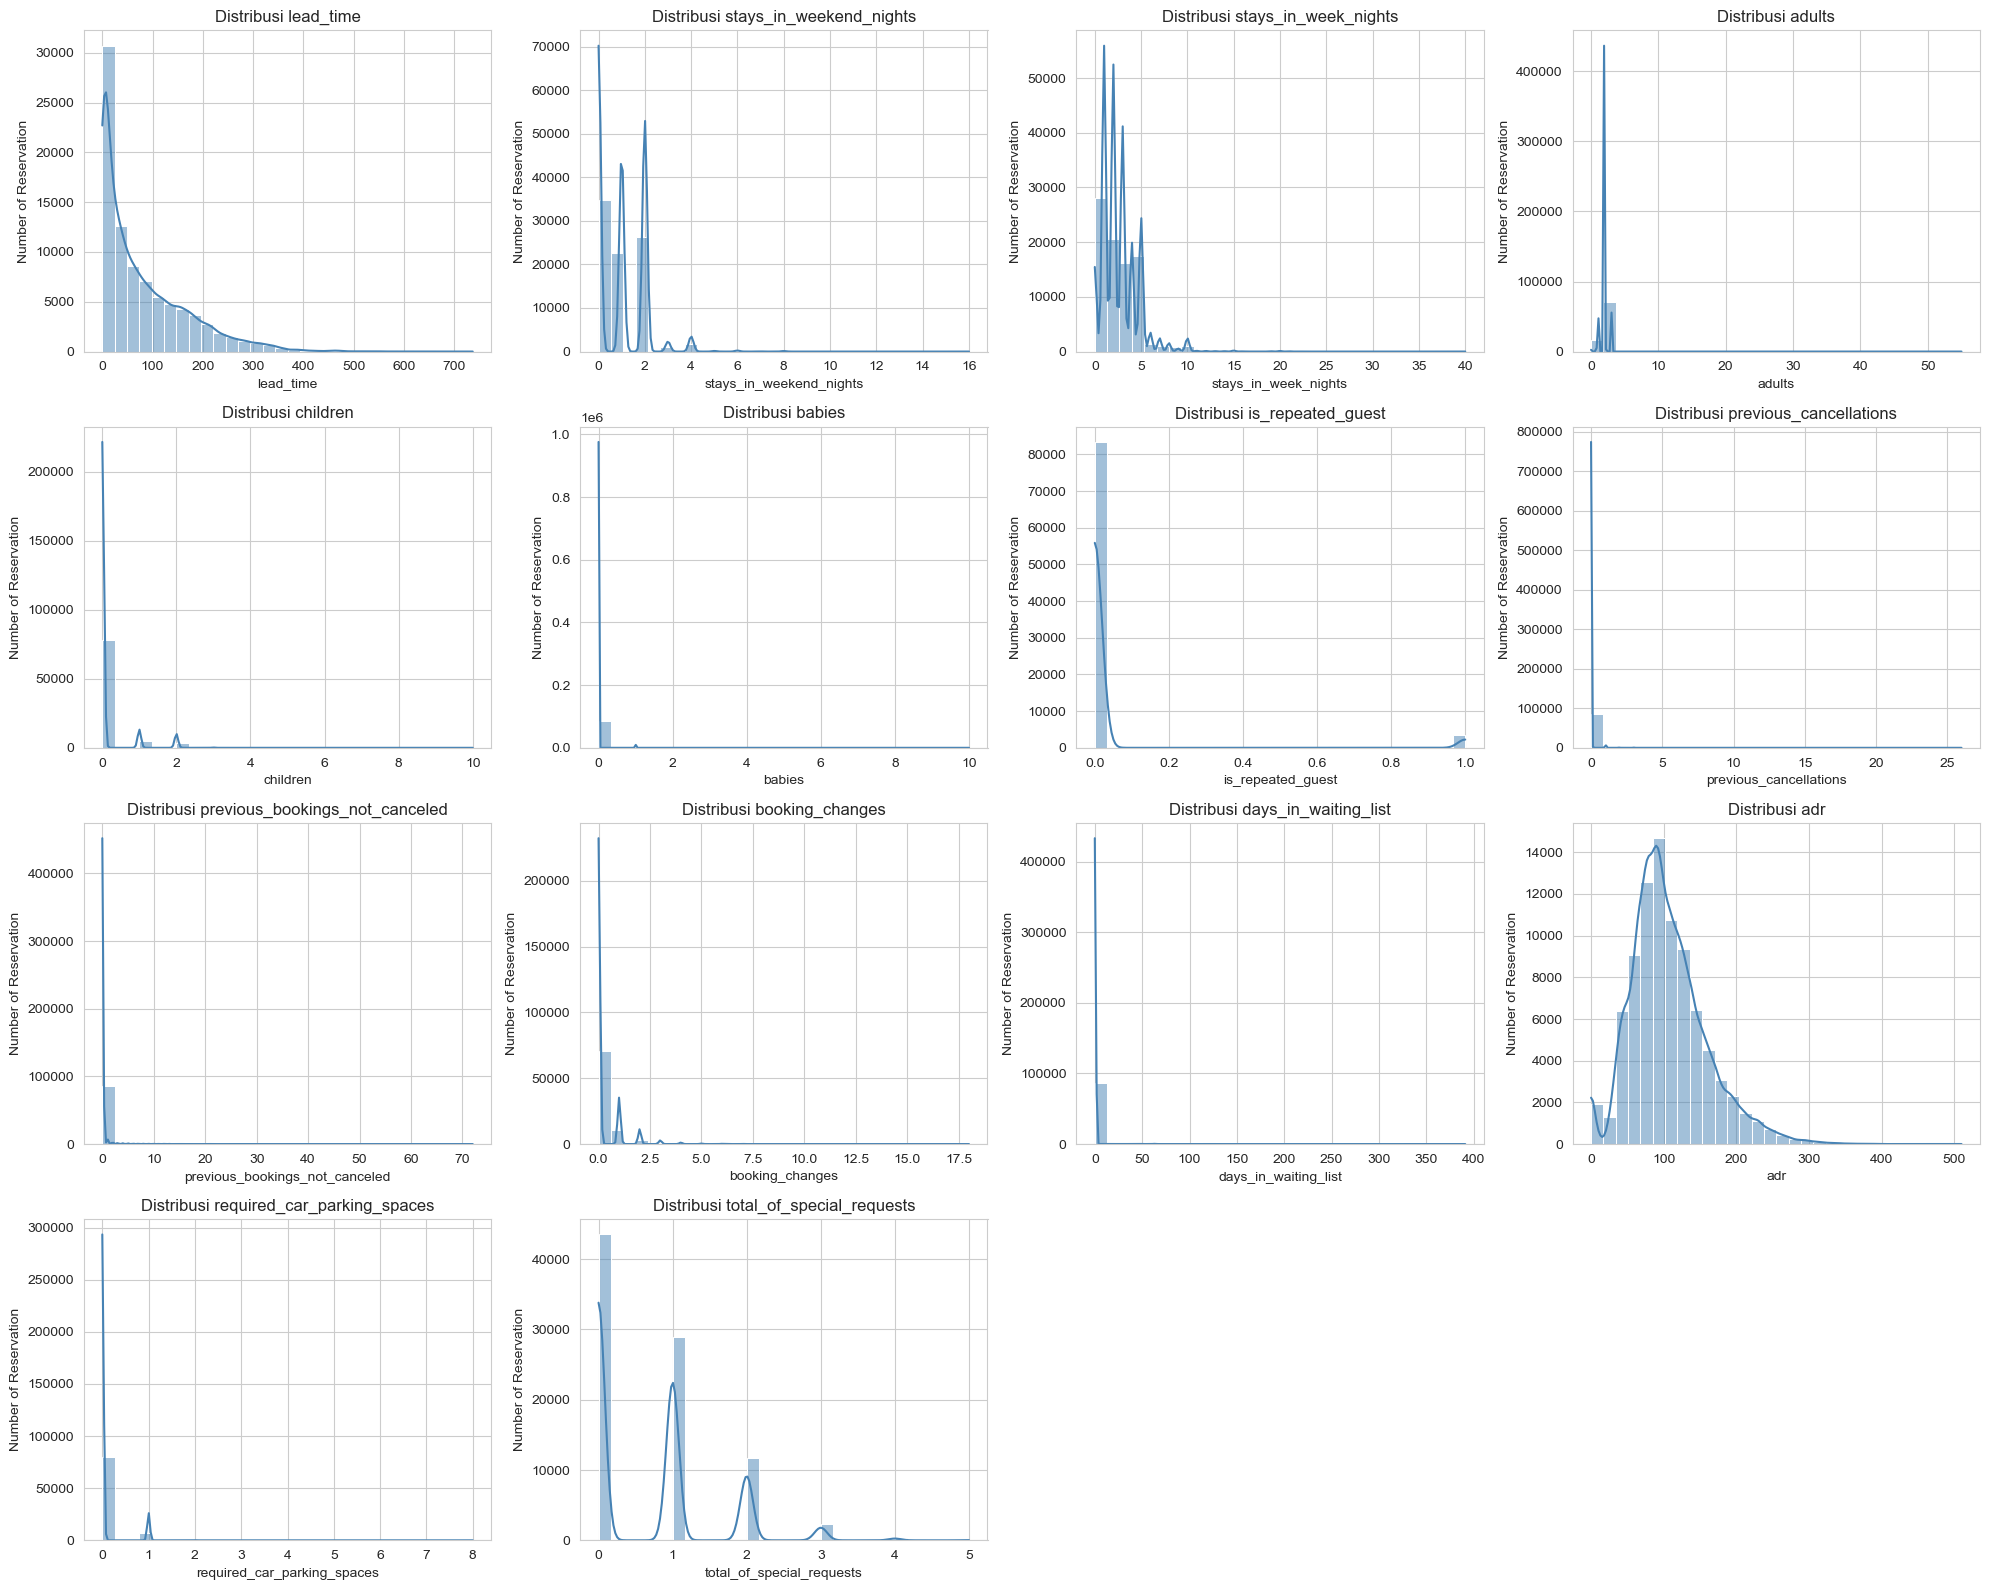

In [18]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_ylabel('Number of Reservation')
    axes[i].set_xlabel(col)
    axes[i].set_title(f'Distribusi {col}')
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**Insight Univariate (Numerik):**
- Mayoritas fitur numerik **sangat right-skewed** (`lead_time`, `previous_cancellations`, `booking_changes`, `days_in_waiting_list`, `adr`) banyak tamu dengan nilai kecil/nol, tapi ada ekor panjang nilai ekstrem.
- `adults` didominasi nilai 2 (booking berpasangan paling umum), `children`/`babies` mayoritas 0.
- `is_repeated_guest` sangat didominasi 0, mayoritas tamu adalah pelanggan baru, bukan *repeat guest*.

### 4.2 Distribusi Fitur Kategorikal

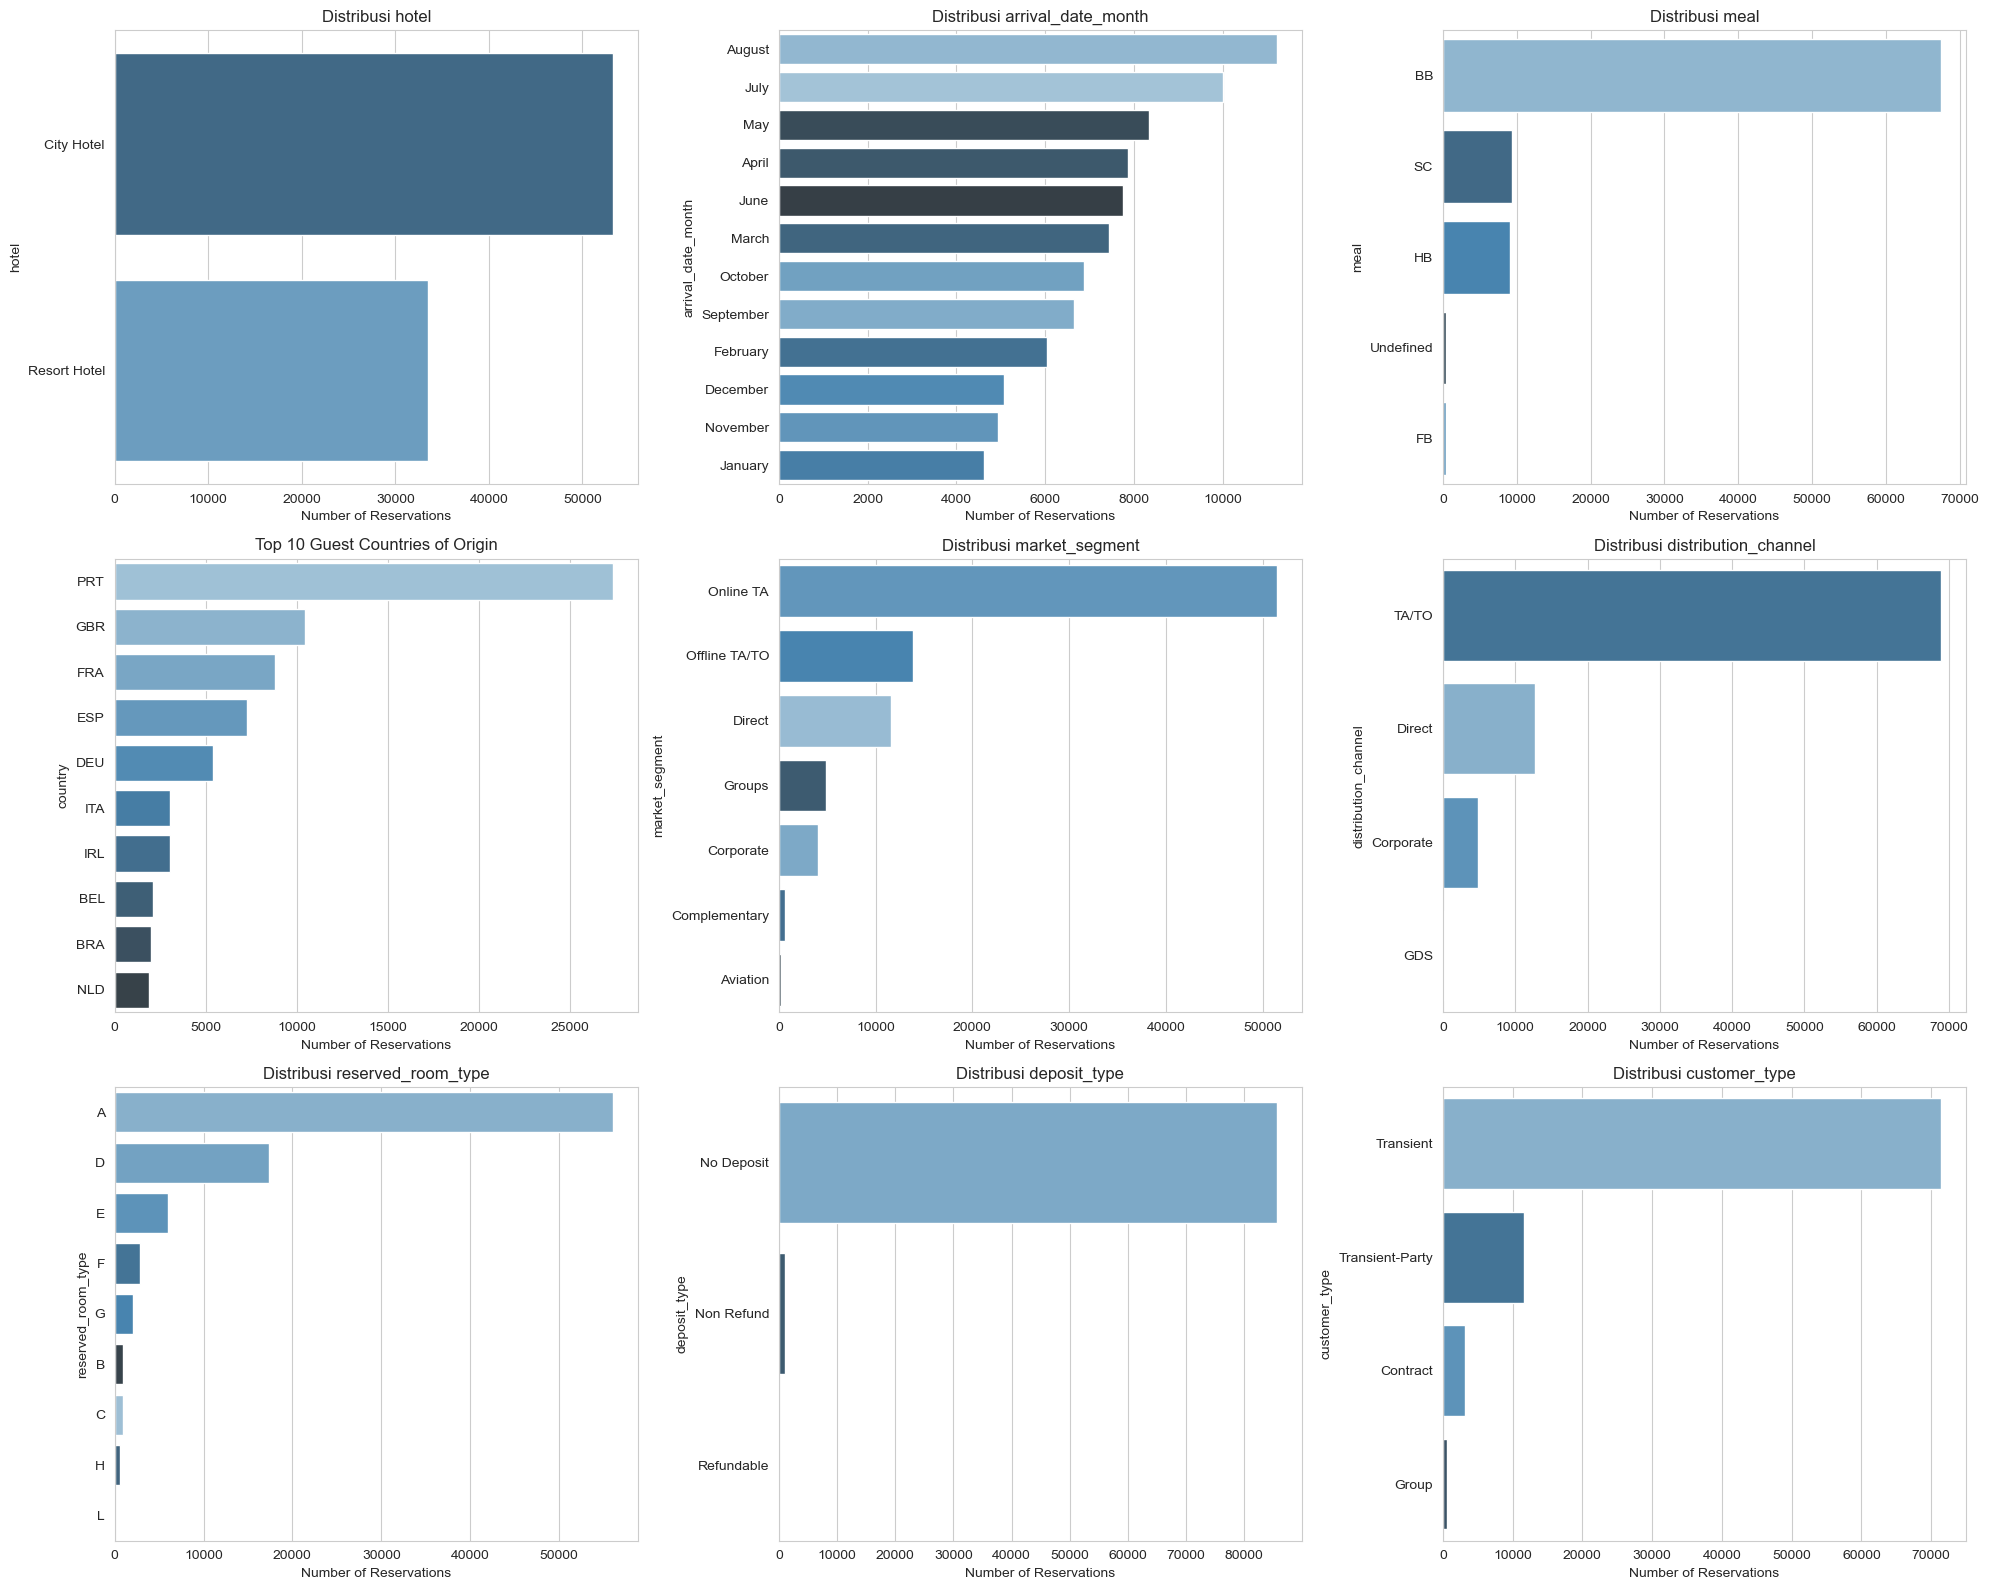

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    if col == 'country':
        top = df['country'].value_counts().head(10)
        sns.barplot(x=top.values, y=top.index, ax=axes[i], hue=top.index, legend=False, palette='Blues_d')
        axes[i].set_title('Top 10 Guest Countries of Origin')
    else:
        order = df[col].value_counts().index
        sns.countplot(data=df, y=col, order=order, ax=axes[i], hue=col, legend=False, palette='Blues_d')
        axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel('Number of Reservations')
plt.tight_layout()
plt.show()

**Insight Univariate (Kategorikal):**
- `hotel`: City Hotel lebih dominan dibanding Resort Hotel.
- `market_segment`: **Online TA** adalah segmen dengan volume booking terbesar, jauh di atas segmen lain.
- `deposit_type`: mayoritas booking **No Deposit**, kebijakan deposit belum jadi standar.
- `customer_type`: didominasi tipe **Transient** (tamu individu, bukan grup/kontrak).
- `country`: Portugal (PRT) adalah negara asal tamu terbanyak, jauh di atas negara lain dan relevan karena hotel pada dataset ini kemungkinan berlokasi di Portugal.

## 5. Bivariate Analysis

Mengaitkan setiap fitur dengan target `is_canceled` untuk melihat pola pembeda antara tamu yang batal vs tidak batal.

### 5.1 Korelasi Fitur Numerik terhadap Target

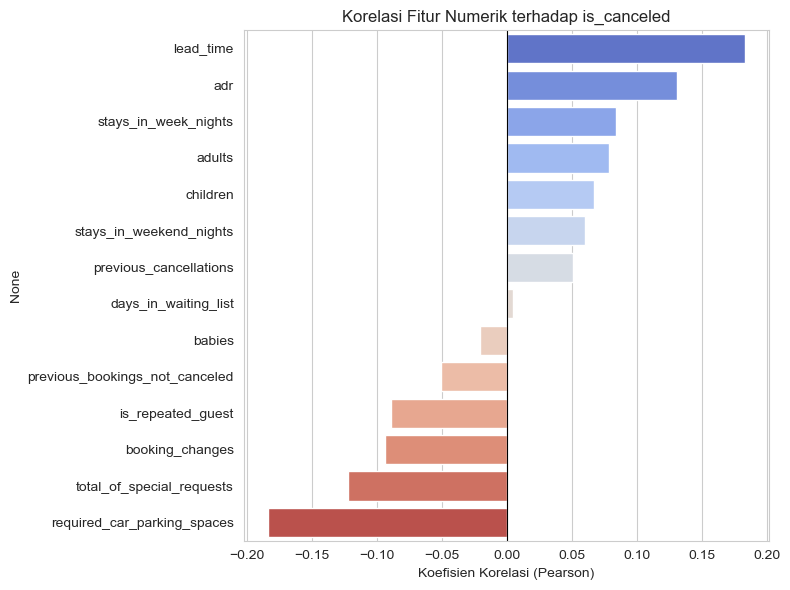

lead_time                         0.183355
adr                               0.131131
stays_in_week_nights              0.084057
adults                            0.078406
children                          0.066823
stays_in_weekend_nights           0.060427
previous_cancellations            0.050988
days_in_waiting_list              0.004542
babies                           -0.020686
previous_bookings_not_canceled   -0.050571
is_repeated_guest                -0.089250
booking_changes                  -0.093680
total_of_special_requests        -0.122098
required_car_parking_spaces      -0.183956
Name: is_canceled, dtype: float64

In [20]:
corr_target = df[num_cols + ['is_canceled']].corr()['is_canceled'].sort_values(ascending=False)
corr_target = corr_target.drop('is_canceled')

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_target.values, y=corr_target.index, hue=corr_target.index, legend=False, palette='coolwarm')
plt.title('Korelasi Fitur Numerik terhadap is_canceled')
plt.xlabel('Koefisien Korelasi (Pearson)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
corr_target

**Insight:** Secara individual, korelasi linear fitur numerik terhadap target **tidak ada yang sangat kuat** (semua |r| < 0.2) yang mengindikasikan bahwa hubungan yang ada kemungkinan besar bersifat non-linear atau berupa interaksi antar fitur (kategorikal khususnya), bukan hubungan linear sederhana. Yang paling menonjol:
- `lead_time` (+0.183) dan `adr` (+0.131) berkorelasi **positif**: semakin jauh hari pemesanan dan semakin mahal kamar, kecenderungan batal makin tinggi.
- `required_car_parking_spaces` (-0.184) dan `total_of_special_requests` (-0.122) berkorelasi **negatif**: tamu yang minta fasilitas tambahan (parkir, special request) cenderung lebih berkomitmen dan jarang batal.

### 5.2 Fitur Kategorikal vs Cancellation Rate

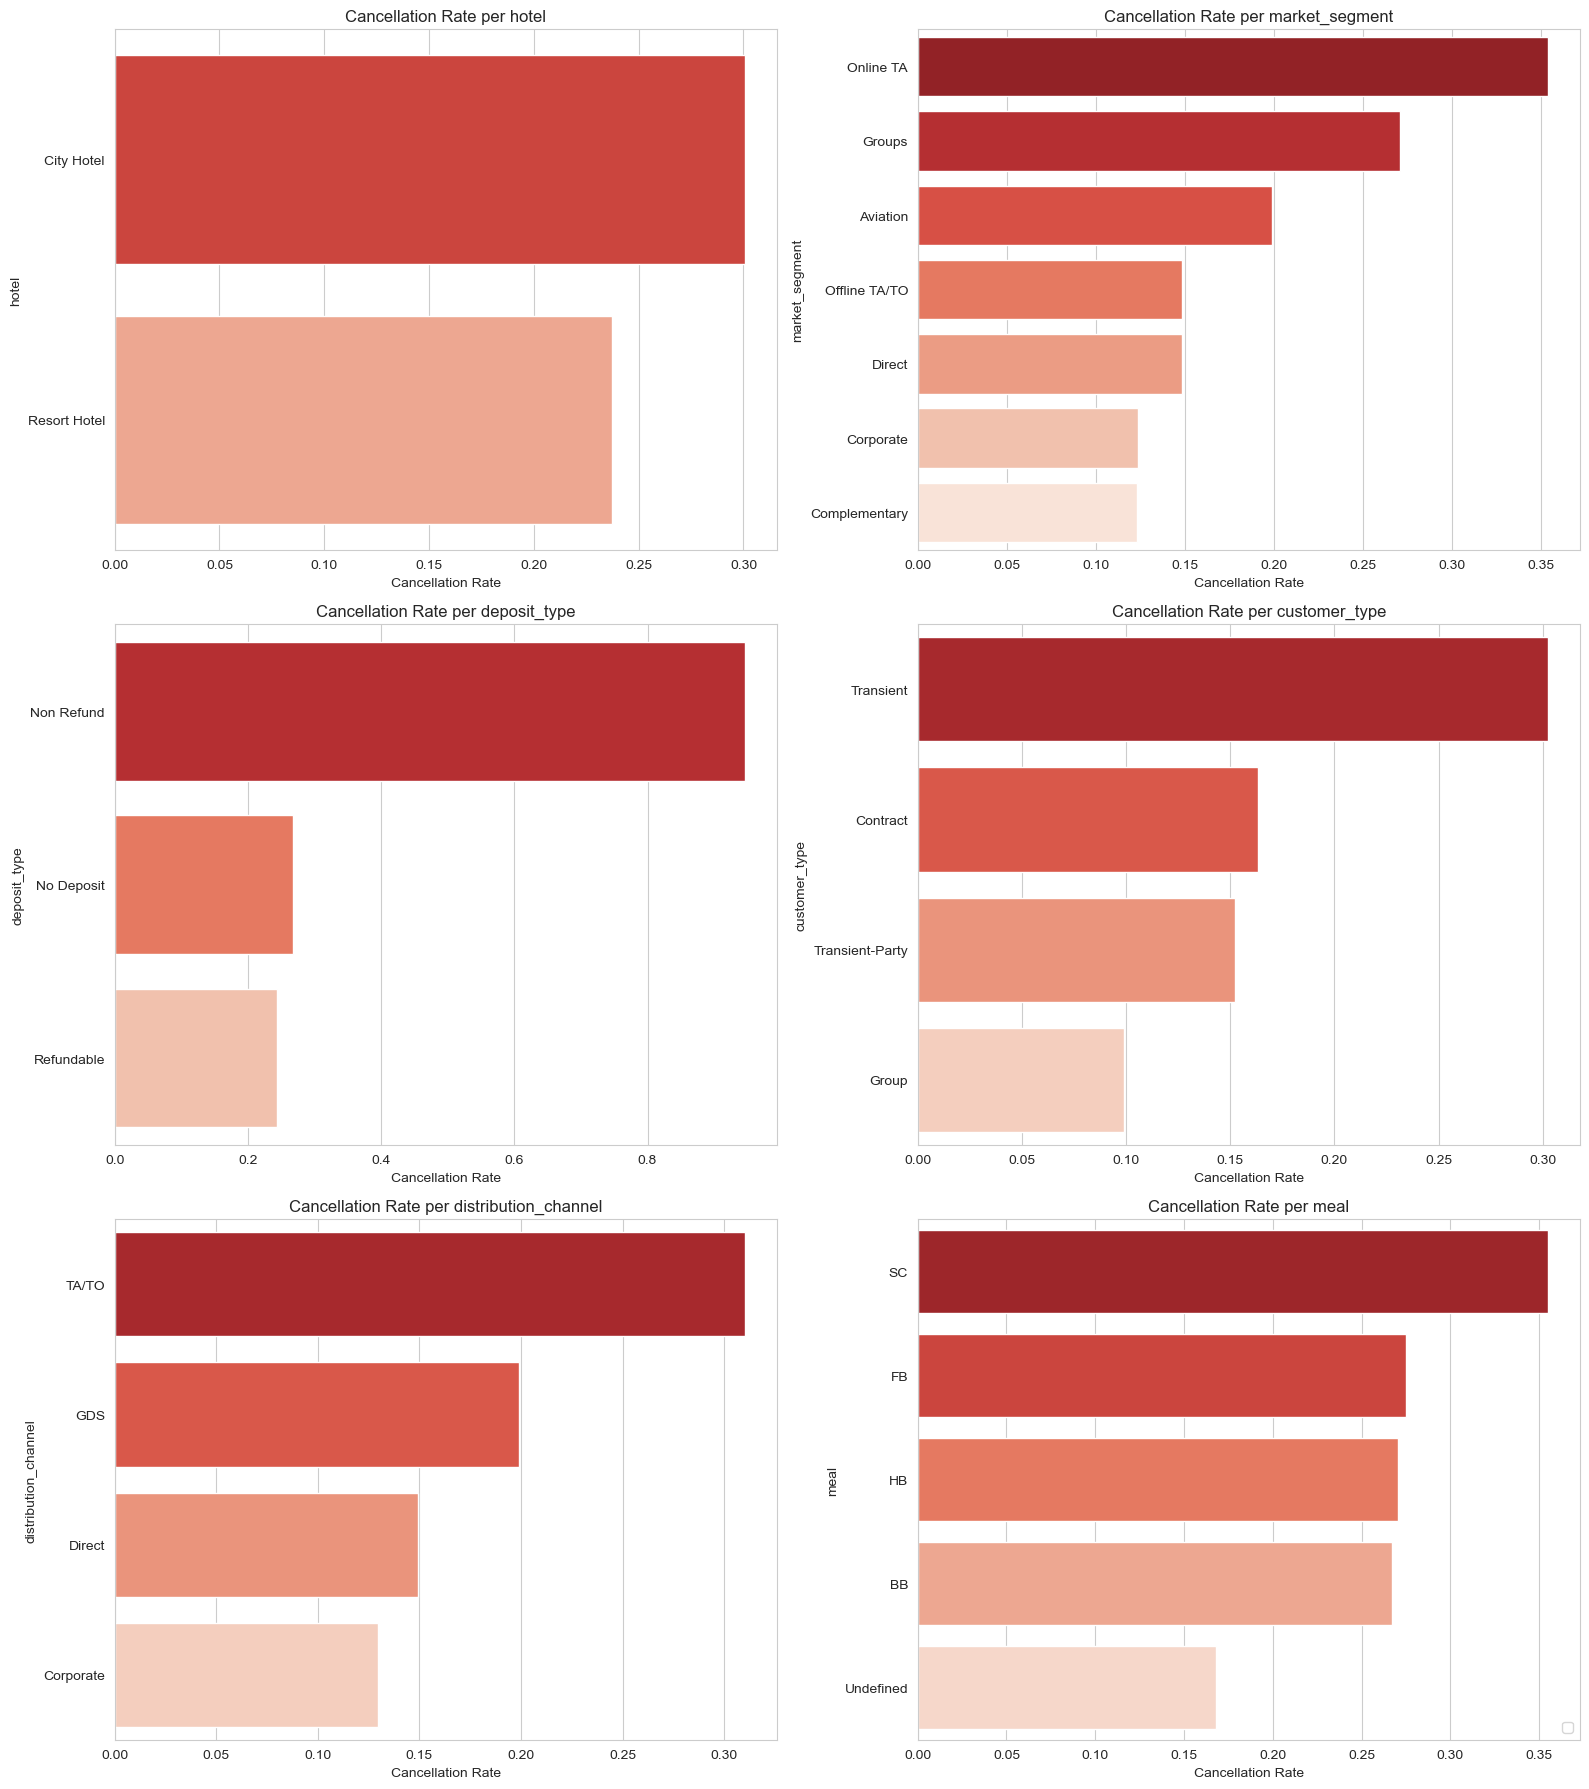

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()
plot_cats = ['hotel', 'market_segment', 'deposit_type', 'customer_type', 'distribution_channel', 'meal']
for i, col in enumerate(plot_cats):
    rate = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, ax=axes[i], hue=rate.index, legend=False, palette='Reds_r')
    axes[i].set_title(f'Cancellation Rate per {col}')
    axes[i].set_xlabel('Cancellation Rate')
axes[i].legend(loc='lower right')
plt.tight_layout()
plt.show()

In [22]:
for c in ['market_segment', 'deposit_type', 'customer_type']:
    print(f"--- {c} ---")
    print(df.groupby(c)['is_canceled'].agg(['mean','count']).sort_values('mean', ascending=False).round(3))
    print()

--- market_segment ---
                 mean  count
market_segment              
Online TA       0.354  51478
Groups          0.271   4916
Aviation        0.199    226
Offline TA/TO   0.148  13824
Direct          0.148  11622
Corporate       0.124   4020
Complementary   0.123    690

--- deposit_type ---
               mean  count
deposit_type              
Non Refund    0.947   1036
No Deposit    0.268  85633
Refundable    0.243    107

--- customer_type ---
                  mean  count
customer_type                
Transient        0.303  71451
Contract         0.163   3135
Transient-Party  0.152  11655
Group            0.099    535



**Insight Bivariate (Kategorikal):**
- **`deposit_type = Non Refund`** memiliki cancellation rate **ekstrem (94,7%)** dan jauh di atas `No Deposit` (26,8%) dan `Refundable` (24,3%). Ini **berlawanan dengan asumsi umum** bahwa deposit non-refund seharusnya menekan pembatalan, selanjutnya akan diinvestigasi lebih lanjut di bagian Multivariate Analysis.
- **`market_segment = Online TA`** memiliki cancellation rate tertinggi kedua (~35%) sekaligus **volume booking terbesar**. Kombinasi *rate* dan *volume* menjadikannya kontributor risiko dominan.
- **City Hotel** > **Resort Hotel** dari sisi cancellation rate, konsisten dengan dugaan bahwa booking city hotel lebih terkait perjalanan bisnis yang jadwalnya mudah berubah.
- **Customer type Transient** (individu, tanpa kontrak/grup) juga cenderung lebih sering batal dibanding Contract/Group.

### 5.3 Fitur Numerik vs Target (Boxplot)

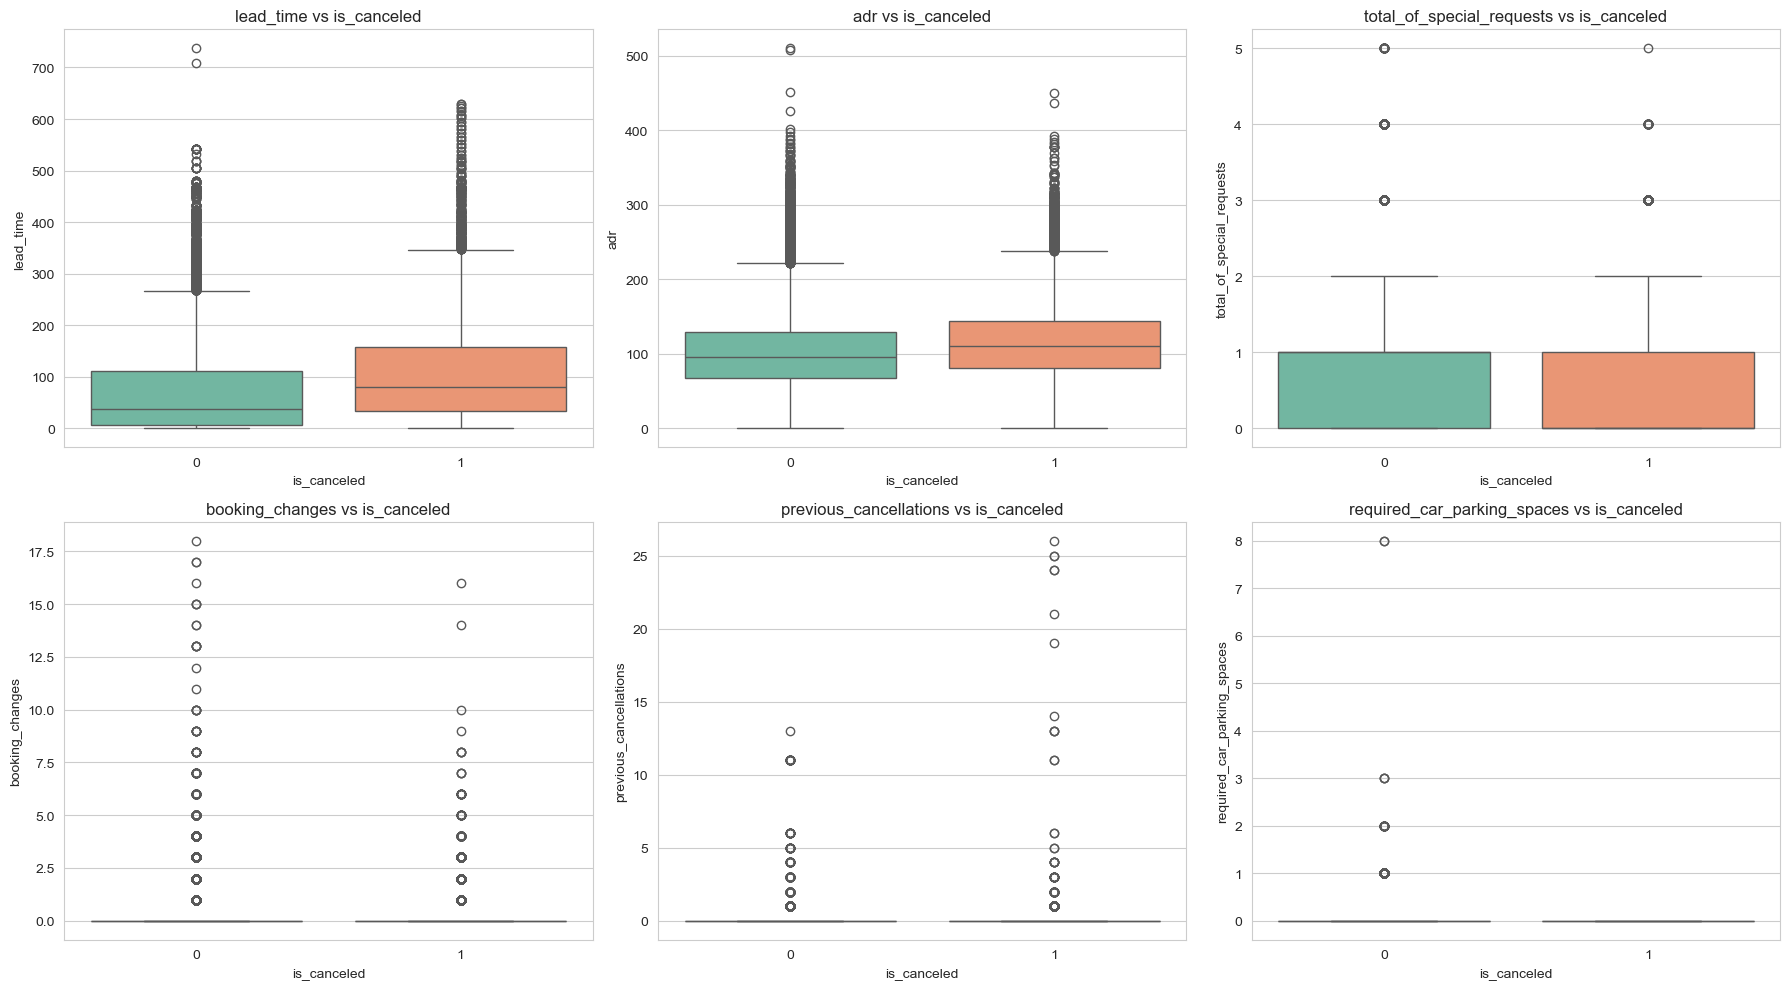

In [23]:
box_cols = ['lead_time', 'adr', 'total_of_special_requests', 'booking_changes',
            'previous_cancellations', 'required_car_parking_spaces']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(box_cols):
    sns.boxplot(data=df, x='is_canceled', y=col, hue='is_canceled', legend=False, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs is_canceled')
plt.tight_layout()
plt.show()

**Insight:** Tamu yang membatalkan reservasi (`is_canceled=1`) secara median memiliki **`lead_time` dan `adr` yang lebih tinggi**, serta **`total_of_special_requests` dan `required_car_parking_spaces` yang lebih rendah**, dibanding tamu yang tidak batal. Temuan sejalan dengan temuan korelasi di 5.1.

## 6. Multivariate Analysis & Pengecekan Korelasi/VIF

Melihat interaksi antar lebih dari dua fitur sekaligus, serta memastikan tidak ada multikolinearitas berlebih antar fitur numerik sebelum modeling.

### 6.1 Correlation Heatmap Antar Fitur Numerik

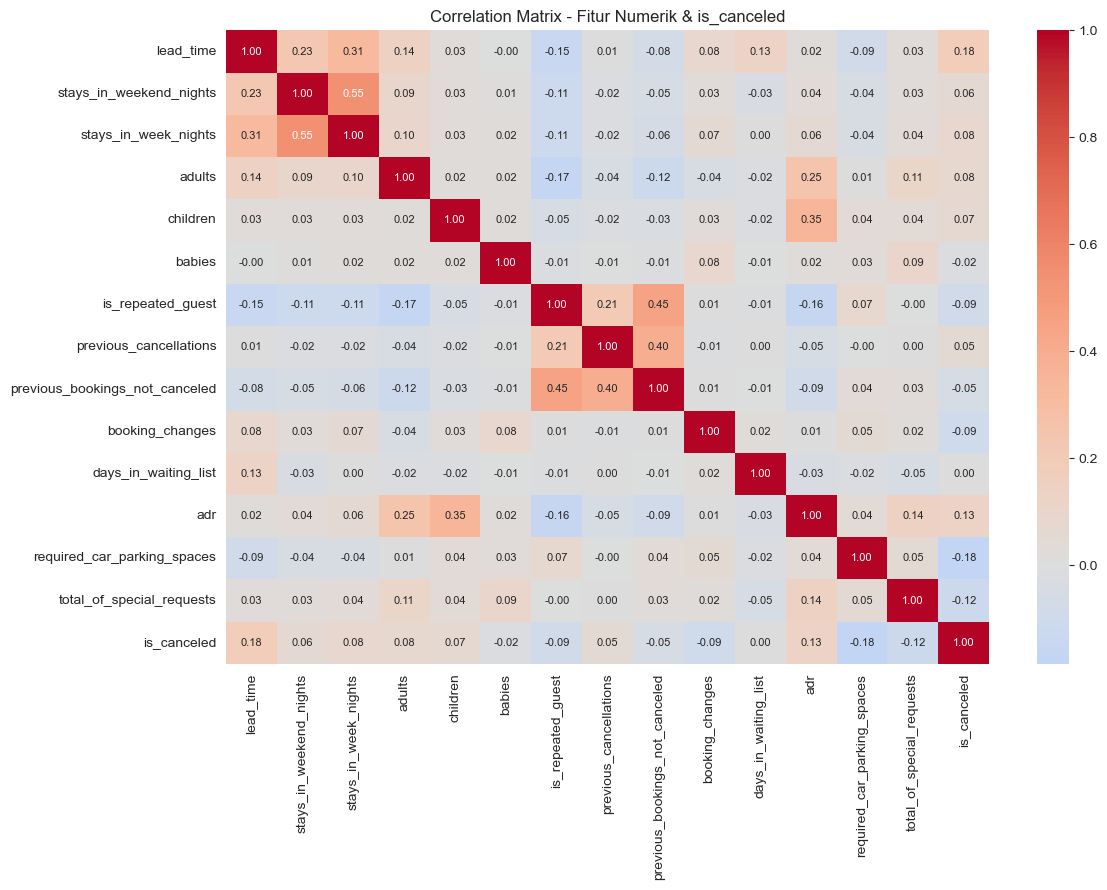

In [24]:
plt.figure(figsize=(12, 9))
corr_matrix = df[num_cols + ['is_canceled']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size':8})
plt.title('Correlation Matrix - Fitur Numerik & is_canceled')
plt.tight_layout()
plt.show()

**Insight:** Tidak terlihat pasangan fitur numerik dengan korelasi sangat tinggi (>0.7) satu sama lain, artinya secara kasar tidak ada indikasi kuat multikolinearitas hanya dari melihat heatmap. Untuk memastikan ini secara lebih ketat, kita hitung **VIF (Variance Inflation Factor)** di bawah.

### 6.2 VIF (Variance Inflation Factor)

VIF mengukur seberapa besar varians koefisien sebuah fitur "terinflasi" akibat berkorelasi dengan fitur lain. Rule of thumb: **VIF > 5** mengindikasikan multikolinearitas yang perlu diperhatikan, **VIF > 10** sudah bermasalah serius.

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif = sm.add_constant(df[num_cols])
vif_df = pd.DataFrame()
vif_df['Fitur'] = X_vif.columns
vif_df['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_df = vif_df[vif_df['Fitur'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)
vif_df

,Fitur,VIF
0,stays_in_week_nights,1.509270
1,stays_in_weekend_nights,1.442555
2,previous_bookings_not_canceled,1.431144
3,is_repeated_guest,1.319918
4,adr,1.257700
5,previous_cancellations,1.190683
6,lead_time,1.180776
7,children,1.145196
8,adults,1.124896
9,total_of_special_requests,1.044194


**Insight VIF:** Seluruh fitur numerik memiliki **VIF < 2**, jauh di bawah ambang batas 5, artinya **tidak ada masalah multikolinearitas** yang berarti antar fitur numerik.


### 6.3 Interaksi Antar Fitur Kategorikal — Investigasi Anomali `Non Refund`

In [26]:
nr = df[df['deposit_type'] == 'Non Refund']
print("Jumlah booking Non Refund:", len(nr), "| Cancellation rate:", round(nr['is_canceled'].mean()*100, 1), "%")
print()
print("Distribusi Non Refund berdasarkan market_segment:")
print(nr['market_segment'].value_counts())
print()
print("Distribusi Non Refund berdasarkan negara (top 5):")
print(nr['country'].value_counts().head())
print()
print("Distribusi Non Refund berdasarkan distribution_channel:")
print(nr['distribution_channel'].value_counts())

Jumlah booking Non Refund: 1036 | Cancellation rate: 94.7 %

Distribusi Non Refund berdasarkan market_segment:
market_segment
Groups           659
Offline TA/TO    285
Corporate         64
Online TA         18
Direct            10
Name: count, dtype: int64

Distribusi Non Refund berdasarkan negara (top 5):
country
PRT    982
GBR     14
DEU     13
ESP      9
FRA      4
Name: count, dtype: int64

Distribusi Non Refund berdasarkan distribution_channel:
distribution_channel
TA/TO        893
Corporate     90
Direct        53
Name: count, dtype: int64


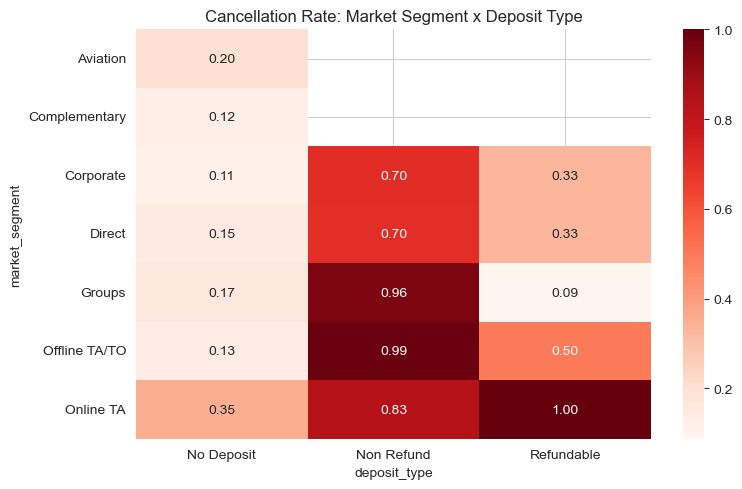

deposit_type,No Deposit,Non Refund,Refundable
market_segment,,,
Aviation,0.199115,NaN,NaN
Complementary,0.123188,NaN,NaN
Corporate,0.114091,0.703125,0.333333
Direct,0.147682,0.700000,0.333333
Groups,0.165909,0.959029,0.087500
Offline TA/TO,0.130624,0.989474,0.500000
Online TA,0.354002,0.833333,1.000000


In [27]:
pivot_seg_dep = df.pivot_table(index='market_segment', columns='deposit_type', values='is_canceled', aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(pivot_seg_dep, annot=True, fmt='.2f', cmap='Reds')
plt.title('Cancellation Rate: Market Segment x Deposit Type')
plt.tight_layout()
plt.show()
pivot_seg_dep

**Insight Multivariate:** Booking `Non Refund` yang cancel nya ekstrem tinggi **terkonsentrasi di negara Portugal (~95% dari seluruh booking Non Refund)** dan didominasi channel **TA/TO (travel agent/tour operator)** pada segmen **Groups** dan **Offline TA/TO**, bukan tersebar merata di semua negara/segmen. Pola ini **sangat mencurigakan sebagai perilaku channel/agent tertentu** (kemungkinan agen yang memblokir kamar dengan skema non-refund lalu membatalkannya secara sistematis), **bukan murni perilaku psikologis tamu individu**.


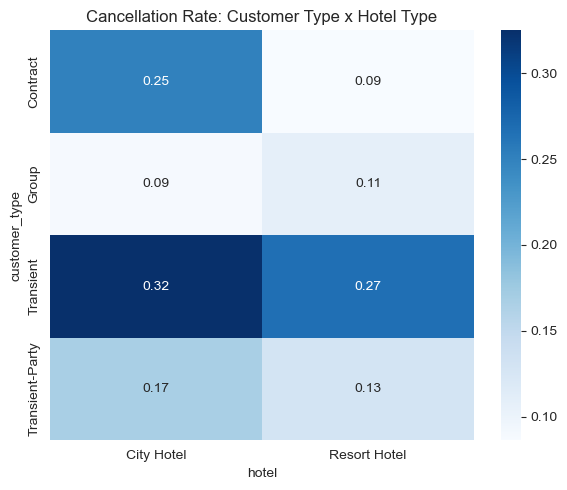

hotel,City Hotel,Resort Hotel
customer_type,,
Contract,0.250852,0.086331
Group,0.089552,0.108614
Transient,0.324843,0.266273
Transient-Party,0.167594,0.129630


In [28]:
pivot_hotel_cust = df.pivot_table(index='customer_type', columns='hotel', values='is_canceled', aggfunc='mean')
plt.figure(figsize=(6,5))
sns.heatmap(pivot_hotel_cust, annot=True, fmt='.2f', cmap='Blues')
plt.title('Cancellation Rate: Customer Type x Hotel Type')
plt.tight_layout()
plt.show()
pivot_hotel_cust

**Insight:** Pola "City Hotel lebih rawan batal" **tidak berlaku merata di semua tipe pemesan**, untuk `customer_type = Group`, Resort Hotel justru sedikit lebih tinggi cancellation rate-nya dibanding City Hotel. Ini contoh interaksi yang tidak akan terlihat jika hanya melihat `hotel` atau `customer_type` secara terpisah (univariate/bivariate saja).

## 7. Explanatory Data Analysis

Merangkum EDA di atas menjadi 5 pertanyaan bisnis konkret yang berkaitan langsung dengan objective: **mengurangi jumlah kamar kosong akibat pembatalan**.

### Pertanyaan 1: Apakah waktu pemesanan (`lead_time`) mempengaruhi risiko pembatalan?

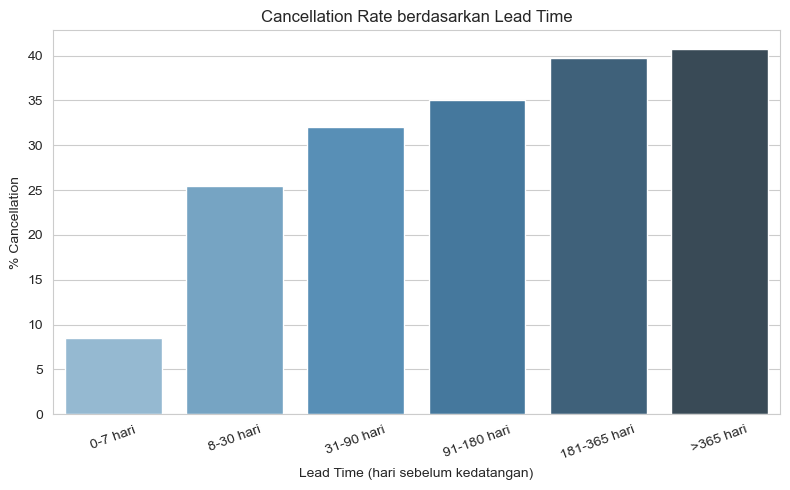

lead_time_bin
0-7 hari         8.482816
8-30 hari       25.444479
31-90 hari      32.063828
91-180 hari     35.055229
181-365 hari    39.699436
>365 hari       40.780142
Name: is_canceled, dtype: float64

In [29]:
bins = [-1, 7, 30, 90, 180, 365, 10000]
labels = ['0-7 hari', '8-30 hari', '31-90 hari', '91-180 hari', '181-365 hari', '>365 hari']
df['lead_time_bin'] = pd.cut(df['lead_time'], bins=bins, labels=labels)

lead_cancel = df.groupby('lead_time_bin', observed=True)['is_canceled'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=lead_cancel.index, y=lead_cancel.values, hue=lead_cancel.index, legend=False, palette='Blues_d')
plt.title('Cancellation Rate berdasarkan Lead Time')
plt.xlabel('Lead Time (hari sebelum kedatangan)')
plt.ylabel('% Cancellation')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()
lead_cancel

**Insight 1:** Pola naik yang jelas dan hampir monoton. Cancellation rate meningkat tajam seiring bertambahnya lead time, dari booking last-minute (H-7) hingga booking di atas satu tahun sebelumnya.

**Implikasi bisnis:** Booking dengan lead time panjang (>90 hari) layak dikenakan kebijakan mitigasi ekstra (deposit, konfirmasi ulang H-30/H-7) karena risiko batalnya jauh lebih tinggi dibanding booking last-minute.

### Pertanyaan 2: Apakah jenis hotel (City vs Resort) memiliki pola pembatalan berbeda?

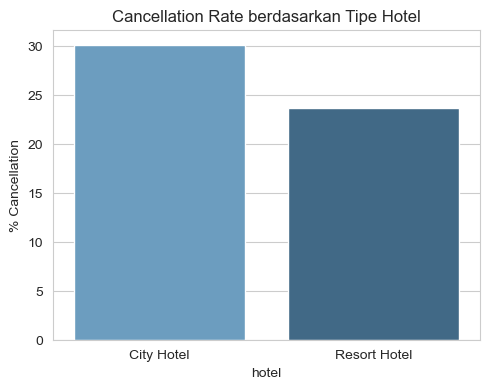

,Cancellation Rate,Jumlah Booking
hotel,,
City Hotel,30.092367,53266
Resort Hotel,23.712325,33510


In [30]:
hotel_cancel = df.groupby('hotel')['is_canceled'].agg(['mean', 'count'])
hotel_cancel.columns = ['Cancellation Rate', 'Jumlah Booking']
hotel_cancel['Cancellation Rate'] = hotel_cancel['Cancellation Rate'] * 100

plt.figure(figsize=(5, 4))
sns.barplot(x=hotel_cancel.index, y=hotel_cancel['Cancellation Rate'], hue=hotel_cancel.index, legend=False, palette='Blues_d')
plt.title('Cancellation Rate berdasarkan Tipe Hotel')
plt.ylabel('% Cancellation')
plt.tight_layout()
plt.show()
hotel_cancel

**Insight 2:** **City Hotel** memiliki cancellation rate lebih tinggi dibanding **Resort Hotel**. Booking city hotel umumnya terkait perjalanan bisnis/urban yang jadwalnya lebih mudah berubah, sedangkan resort umumnya untuk liburan yang direncanakan lebih matang. Namun ingat temuan multivariate di bagian 6.3: pola ini tidak berlaku merata untuk semua `customer_type`.

**Implikasi bisnis:** Kebijakan mitigasi pembatalan sebaiknya diprioritaskan/diperketat untuk properti **City Hotel**, kecuali untuk segmen `Group` yang polanya justru terbalik.

### Pertanyaan 3: Bulan/musim apa dengan cancellation rate tertinggi?

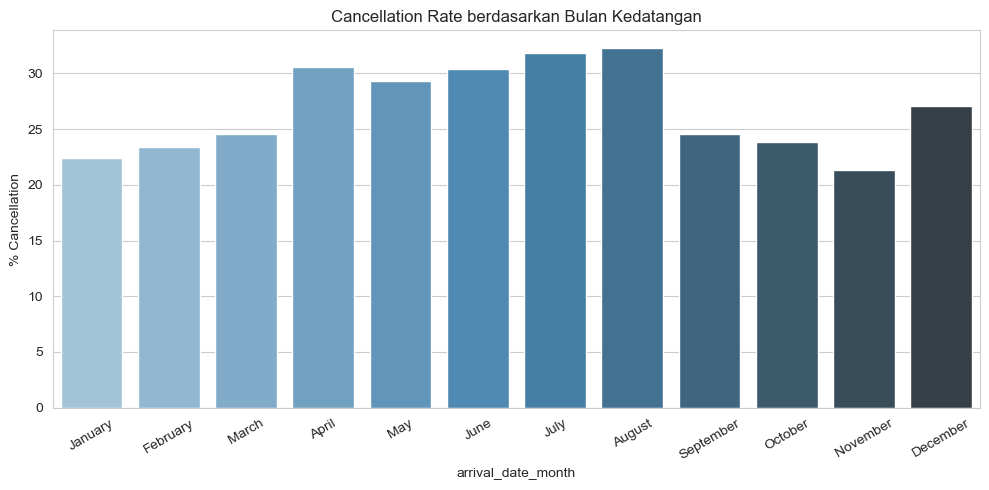

arrival_date_month
January      22.375810
February     23.420136
March        24.579578
April        30.544252
May          29.308689
June         30.371901
July         31.871316
August       32.245698
September    24.582770
October      23.828239
November     21.325765
December     27.112954
Name: is_canceled, dtype: float64

In [31]:
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
month_cancel = df.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order)* 100

plt.figure(figsize=(10, 5))
sns.barplot(x=month_cancel.index, y=month_cancel.values, hue=month_cancel.index, legend=False, palette='Blues_d')
plt.title('Cancellation Rate berdasarkan Bulan Kedatangan')
plt.ylabel('% Cancellation')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
month_cancel

**Insight 3:** Cancellation rate cenderung lebih tinggi pada bulan-bulan **peak season (April-Agustus)** dibanding *low season* (Januari-Maret & September-November). Polanya tidak sangat ekstrem, tapi cukup konsisten.

### Pertanyaan 4: Apakah kebijakan deposit (`deposit_type`) efektif menekan pembatalan?

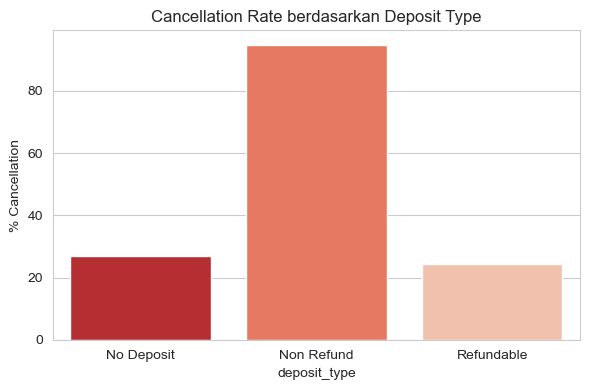

,Cancellation Rate,Jumlah Booking
deposit_type,,
No Deposit,26.821436,85633
Non Refund,94.691120,1036
Refundable,24.299065,107


In [32]:
deposit_cancel = df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count'])
deposit_cancel.columns = ['Cancellation Rate', 'Jumlah Booking']
deposit_cancel['Cancellation Rate'] *= 100

plt.figure(figsize=(6, 4))
sns.barplot(x=deposit_cancel.index, y=deposit_cancel['Cancellation Rate'], hue=deposit_cancel.index, legend=False, palette='Reds_r')
plt.title('Cancellation Rate berdasarkan Deposit Type')
plt.ylabel('% Cancellation')
plt.tight_layout()
plt.show()
deposit_cancel

**Insight 4:** Booking `Non Refund` justru memiliki cancellation rate **ekstrem tinggi (~94,7%)**, berlawanan dengan asumsi umum. Namun analisis multivariate menunjukkan pola ini **terkonsentrasi di Portugal via channel TA/TO**, bukan perilaku tamu individu secara umum ini kemungkinan besar mencerminkan praktik bisnis agen tertentu, bukan sinyal murni "deposit non-refund menyebabkan pembatalan".

### Pertanyaan 5: Segmen pasar mana yang paling banyak menyumbang pembatalan?

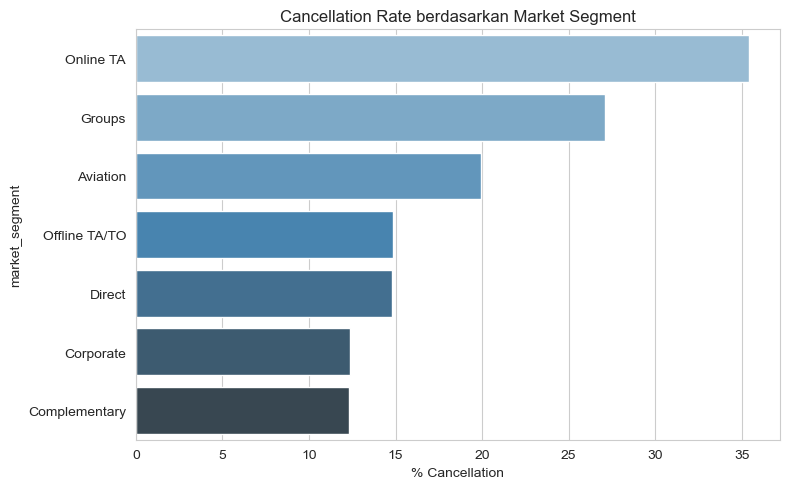

,Cancellation Rate,Jumlah Booking
market_segment,,
Online TA,35.434555,51478
Groups,27.095199,4916
Aviation,19.911504,226
Offline TA/TO,14.843750,13824
Direct,14.825331,11622
Corporate,12.363184,4020
Complementary,12.318841,690


In [33]:
segment_cancel = df.groupby('market_segment')['is_canceled'].agg(['mean', 'count']).sort_values('mean', ascending=False)
segment_cancel.columns = ['Cancellation Rate', 'Jumlah Booking']
segment_cancel['Cancellation Rate'] *= 100

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_cancel['Cancellation Rate'], y=segment_cancel.index, hue=segment_cancel.index, legend=False, palette='Blues_d')
plt.title('Cancellation Rate berdasarkan Market Segment')
plt.xlabel('% Cancellation')
plt.tight_layout()
plt.show()
segment_cancel

**Insight 5:** **Online TA** memiliki cancellation rate tertinggi sekaligus volume booking terbesar menjadikannya kontributor risiko terbesar baik dari sisi *rate* maupun *volume absolut*. **Groups** berada di urutan kedua, sementara Offline TA/TO, Direct, Corporate, dan Complementary relatif rendah.

**Implikasi bisnis:** Online TA layak menjadi prioritas utama mitigasi, dengan Groups sebagai prioritas kedua.

### Ringkasan 5 Pertanyaan EDA

1. **Lead time panjang** = risiko pembatalan lebih tinggi (indikator terkuat, dikonfirmasi juga oleh feature importance model di bagian 11).
2. **City Hotel** lebih berisiko dibanding Resort Hotel, kecuali untuk segmen Group.
3. **Peak season (Apr-Agu)** memiliki cancellation rate sedikit lebih tinggi dibanding low season.
4. **Deposit Non Refund** berasosiasi dengan cancellation rate ekstrem tinggi, namun ini kemungkinan pola channel/agent spesifik (Portugal, TA/TO) dan  perlu investigasi lanjutan, bukan kesimpulan final.
5. **Online TA** adalah segmen dengan kombinasi *rate* dan *volume* pembatalan tertinggi; **Groups** menyusul di urutan kedua.

## 8. Data Preprocessing untuk Modeling

| Kolom | Perlakuan | Alasan |
| --- | --- | --- |
| `country` | Dikelompokkan: 15 negara terbanyak + `Other` | Kategori sangat banyak (~170), disederhanakan agar One-Hot tidak meledak jumlah kolomnya |
| Kolom kategorikal lain (`hotel`, `arrival_date_month`, `meal`, `market_segment`, `distribution_channel`, `reserved_room_type`, `deposit_type`, `customer_type`, `country_grp`) | One-Hot Encoding | Sederhana, tidak butuh asumsi urutan kategori, dan hasil dari EDA (bagian 5-7) menunjukkan hubungan tiap kategori dengan target tidak bersifat ordinal yang jelas |
| Semua kolom numerik | Standard Scaler | Menyamakan skala antar fitur, VIF sudah mengonfirmasi tidak ada isu multikolinearitas (bagian 6.2), jadi scaling murni untuk kebutuhan model berbasis jarak/gradient (Logistic Regression, KNN) |

In [34]:
top_countries = df['country'].value_counts().head(15).index.tolist()
df['country_grp'] = df['country'].apply(lambda x: x if x in top_countries else 'Other')
df_model = df.drop(columns=['country', 'lead_time_bin'])

X = df_model.drop(columns=['is_canceled'])
y = df_model['is_canceled']

cat_cols = ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel',
            'reserved_room_type', 'deposit_type', 'customer_type', 'country_grp']
num_cols = [c for c in X.columns if c not in cat_cols]

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Jumlah fitur kategorikal:", len(cat_cols), "| Jumlah fitur numerik:", len(num_cols))
print(f"Proporsi target train -> 0: {(y_train==0).mean():.1%} | 1: {(y_train==1).mean():.1%}")

Train shape: (69420, 23) | Test shape: (17356, 23)
Jumlah fitur kategorikal: 9 | Jumlah fitur numerik: 14
Proporsi target train -> 0: 72.4% | 1: 27.6%


Target masih imbalanced (~72% : 28%). Alih-alih memakai SMOTE (bisa menghasilkan data sintetis kategorikal yang kurang valid dan menambah kompleksitas), kita memakai parameter **`class_weight='balanced'`** (untuk model scikit-learn) dan **`scale_pos_weight`** (untuk model boosting), pendekatan yang membuat model lebih peka terhadap kelas minoritas tanpa mengubah data training sama sekali.

In [35]:
scale_pos_weight = float((y_train == 0).sum() / (y_train == 1).sum())
print(f"scale_pos_weight (rasio kelas 0 / kelas 1): {scale_pos_weight:.3f}")

scale_pos_weight (rasio kelas 0 / kelas 1): 2.619


## 9. Model Benchmarking

Membandingkan 8 model klasifikasi dengan parameter dasar (near-default) pada train/test split yang sama, untuk melihat model mana yang paling menjanjikan sebelum masuk ke tahap tuning yang lebih mahal secara komputasi.

In [36]:
import time
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (classification_report, roc_auc_score, average_precision_score,
                              recall_score, precision_score, f1_score)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=12),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=14, class_weight='balanced',
                                             random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, verbose=-1),
    "CatBoost": CatBoostClassifier(scale_pos_weight=scale_pos_weight, random_state=42, verbose=0),
}

benchmark_results = []
fitted_benchmark = {}
for name, model in models.items():
    t0 = time.time()
    clf = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    elapsed = time.time() - t0
    benchmark_results.append({
        'Model': name,
        'Recall (kelas 1)': recall_score(y_test, y_pred),
        'Precision (kelas 1)': precision_score(y_test, y_pred),
        'F1 (kelas 1)': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob),
        'Waktu (s)': round(elapsed, 2),
    })
    fitted_benchmark[name] = clf

benchmark_df = pd.DataFrame(benchmark_results).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
benchmark_df

,Model,Recall (kelas 1),Precision (kelas 1),F1 (kelas 1),ROC-AUC,PR-AUC,Waktu (s)
0,CatBoost,0.838373,0.604602,0.702552,0.898492,0.779110,17.07
1,XGBoost,0.826069,0.601245,0.695950,0.894626,0.770877,0.97
2,LightGBM,0.831700,0.590552,0.690682,0.891365,0.763025,0.73
3,Random Forest,0.838165,0.541207,0.657720,0.877728,0.736689,7.51
4,Gradient Boosting,0.542231,0.731776,0.622904,0.873986,0.734027,23.06
5,Decision Tree,0.785401,0.569743,0.660412,0.859554,0.684360,0.98
6,KNN,0.539729,0.696635,0.608226,0.845146,0.679267,6.59
7,Logistic Regression,0.776017,0.527577,0.628123,0.836730,0.665101,1.29


<Figure size 1000x600 with 0 Axes>

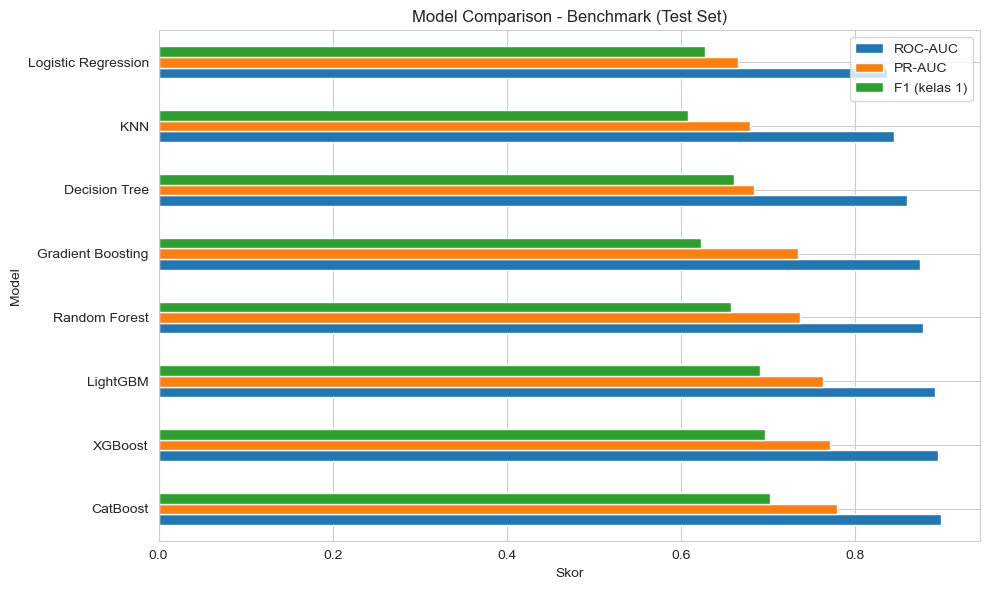

In [37]:
plt.figure(figsize=(10, 6))
plot_df = benchmark_df.set_index('Model')[['ROC-AUC', 'PR-AUC', 'F1 (kelas 1)']]
plot_df.plot(kind='barh', figsize=(10,6))
plt.title('Model Comparison - Benchmark (Test Set)')
plt.xlabel('Skor')
plt.tight_layout()
plt.show()

**Insight Benchmarking:**
- Model **boosting** (CatBoost, XGBoost, LightGBM) secara konsisten mengungguli model dasar (Logistic Regression, KNN, Decision Tree) dan bahkan Random Forest, baik dari sisi ROC-AUC, PR-AUC, maupun F1.
- **Gradient Boosting (sklearn)** performanya biasa saja dan **paling lambat** kalah dari implementasi boosting modern (XGBoost/LightGBM/CatBoost) yang jauh lebih efisien dan lebih baik menangani data imbalanced lewat `scale_pos_weight`.
- **KNN** paling lambat saat prediksi dan performanya tidak kompetitif sehingga tidak akan dilanjutkan ke tahap tuning.
- Berdasarkan **PR-AUC** (metrik paling relevan untuk data imbalanced seperti kasus ini), 3 model teratas adalah: **CatBoost, XGBoost, dan LightGBM**, ketiganya akan dibawa ke tahap berikutnya (Top 3 Model, Tuning & Cross Validation).

## 10. Top 3 Model, Hyperparameter Tuning & Cross Validation

### 10.1 Cross-Validation Awal (Sebelum Tuning)

Sebelum melakukan *hyperparameter tuning* yang mahal secara komputasi, kita cek dulu apakah performa 3 model terbaik dari benchmarking stabil lewat 5-fold cross-validation (yang bukan hanya bagus pada satu train/test split saja).

In [38]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['recall', 'precision', 'f1', 'roc_auc', 'average_precision']

top3_models = {
    "CatBoost": CatBoostClassifier(scale_pos_weight=scale_pos_weight, random_state=42, verbose=0),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, verbose=-1),
}

cv_baseline_results = []
for name, model in top3_models.items():
    clf = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    cvres = cross_validate(clf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    row = {'Model': name}
    for s in scoring:
        row[f'{s}_mean'] = cvres[f'test_{s}'].mean()
        row[f'{s}_std'] = cvres[f'test_{s}'].std()
    cv_baseline_results.append(row)

cv_baseline_df = pd.DataFrame(cv_baseline_results)
cv_baseline_df

,Model,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,CatBoost,0.822680,0.008145,0.600511,0.002526,0.694240,0.003871,0.892362,0.001916,0.764736,0.004613
1,XGBoost,0.816893,0.007330,0.598541,0.004857,0.690859,0.004841,0.890427,0.002026,0.760095,0.003831
2,LightGBM,0.825912,0.006316,0.584454,0.004097,0.684499,0.003853,0.886822,0.001679,0.752858,0.004851


**Insight:** Standar deviasi antar fold kecil (umumnya < 0.01) untuk ketiga model jadi untuk performa stabil. Ketiganya layak dilanjutkan ke tahap *hyperparameter tuning*.

### 10.2 Hyperparameter Tuning
**Catatan:** Scorer yang dipakai untuk `RandomizedSearchCV` di sini adalah **`average_precision` (PR-AUC)**. PR-AUC mengevaluasi kualitas ranking probabilitas di semua kemungkinan threshold, sehingga hasil tuning lebih robust.

In [39]:
from sklearn.model_selection import RandomizedSearchCV

cv_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grids = {
    "CatBoost": {
        'classifier__learning_rate': [0.03, 0.05, 0.1],
        'classifier__depth': [4, 6, 8],
        'classifier__l2_leaf_reg': [1, 3, 5, 7],
        'classifier__iterations': [150, 250, 350],
        'classifier__bagging_temperature': [0, 0.3, 0.7],
    },
    "XGBoost": {
        'classifier__learning_rate': [0.03, 0.05, 0.1, 0.15],
        'classifier__max_depth': [4, 5, 6, 7, 9],
        'classifier__n_estimators': [150, 250, 350],
        'classifier__subsample': [0.7, 0.85, 1.0],
        'classifier__colsample_bytree': [0.7, 0.85, 1.0],
    },
    "LightGBM": {
        'classifier__learning_rate': [0.03, 0.05, 0.1, 0.15],
        'classifier__num_leaves': [15, 31, 45, 63],
        'classifier__n_estimators': [150, 250, 350],
        'classifier__subsample': [0.7, 0.85, 1.0],
        'classifier__colsample_bytree': [0.7, 0.85, 1.0],
    },
}

n_iter_map = {"CatBoost": 8, "XGBoost": 12, "LightGBM": 12}  # CatBoost lebih berat per-fit -> n_iter lebih kecil

tuned_models = {}
search_summary = []
for name, model in top3_models.items():
    clf = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    t0 = time.time()
    rs = RandomizedSearchCV(
        clf, param_grids[name], n_iter=n_iter_map[name], scoring='average_precision',
        cv=cv_tune, random_state=42, n_jobs=-1, verbose=0
    )
    rs.fit(X_train, y_train)
    elapsed = time.time() - t0
    tuned_models[name] = rs.best_estimator_
    search_summary.append({'Model': name, 'Waktu (s)': round(elapsed, 1),
                            'Best PR-AUC (CV tuning)': round(rs.best_score_, 4),
                            'Best Params': rs.best_params_})
    print(f"{name} selesai dalam {elapsed:.1f}s | Best PR-AUC: {rs.best_score_:.4f}")
    print(f"  Best params: {rs.best_params_}\n")

search_summary_df = pd.DataFrame(search_summary)[['Model', 'Waktu (s)', 'Best PR-AUC (CV tuning)']]
search_summary_df

CatBoost selesai dalam 94.7s | Best PR-AUC: 0.7492
  Best params: {'classifier__learning_rate': 0.05, 'classifier__l2_leaf_reg': 3, 'classifier__iterations': 250, 'classifier__depth': 8, 'classifier__bagging_temperature': 0.3}

XGBoost selesai dalam 30.0s | Best PR-AUC: 0.7635
  Best params: {'classifier__subsample': 1.0, 'classifier__n_estimators': 250, 'classifier__max_depth': 9, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}

LightGBM selesai dalam 40.0s | Best PR-AUC: 0.7642
  Best params: {'classifier__subsample': 0.85, 'classifier__num_leaves': 63, 'classifier__n_estimators': 350, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}



,Model,Waktu (s),Best PR-AUC (CV tuning)
0,CatBoost,94.7,0.7492
1,XGBoost,30.0,0.7635
2,LightGBM,40.0,0.7642


LightGBM selesai dalam 62.3s | Best PR-AUC: 0.7642
  Best params: {'classifier__subsample': 0.85, 'classifier__num_leaves': 63, 'classifier__n_estimators': 350, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 0.7}



,Model,Waktu (s),Best PR-AUC (CV tuning)
0,CatBoost,70.5,0.7492
1,XGBoost,68.7,0.7638
2,LightGBM,62.3,0.7642


### 10.3 Cross-Validation Final (Model Setelah Tuning)

Membandingkan ketiga model setelah tuning dengan 5-fold cross-validation pada beberapa metrik sekaligus, untuk memilih model final secara adil (bukan hanya berdasar satu metrik).

In [40]:
scoring_final = ['recall', 'precision', 'f1', 'roc_auc', 'average_precision']
final_cv_results = []
for name, model in tuned_models.items():
    cvres = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring_final, n_jobs=1)
    row = {'Model': f'{name} (tuned)'}
    for s in scoring_final:
        row[f'{s}_mean'] = cvres[f'test_{s}'].mean()
        row[f'{s}_std'] = cvres[f'test_{s}'].std()
    final_cv_results.append(row)

final_cv_df = pd.DataFrame(final_cv_results).sort_values('average_precision_mean', ascending=False).reset_index(drop=True)
final_cv_df

,Model,recall_mean,recall_std,precision_mean,precision_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std
0,LightGBM (tuned),0.820021,0.007872,0.604201,0.002868,0.695748,0.004170,0.894485,0.002187,0.768016,0.004679
1,XGBoost (tuned),0.813034,0.008416,0.605379,0.004130,0.693984,0.004387,0.892741,0.001903,0.766123,0.004195
2,CatBoost (tuned),0.824140,0.008413,0.581460,0.003346,0.681839,0.004596,0.884816,0.001799,0.750458,0.003761


<Figure size 900x500 with 0 Axes>

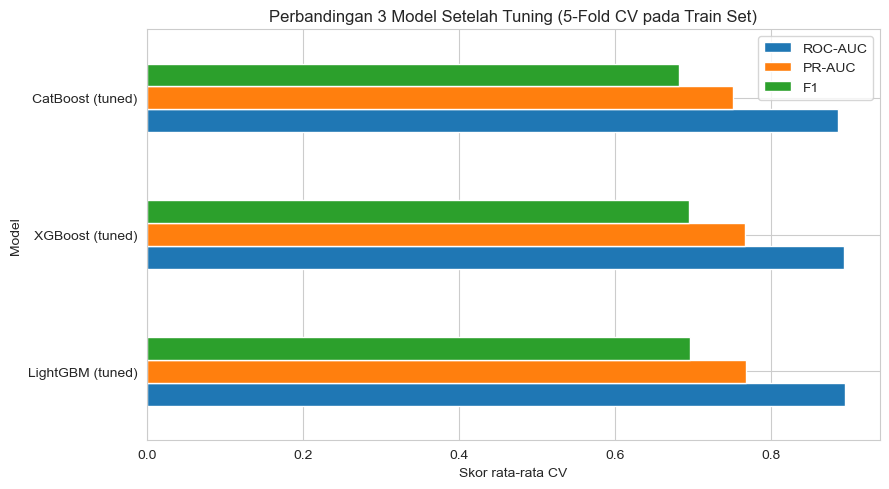

In [41]:
plt.figure(figsize=(9,5))
plot_final = final_cv_df.set_index('Model')[['roc_auc_mean', 'average_precision_mean', 'f1_mean']]
plot_final.columns = ['ROC-AUC', 'PR-AUC', 'F1']
plot_final.plot(kind='barh', figsize=(9,5))
plt.title('Perbandingan 3 Model Setelah Tuning (5-Fold CV pada Train Set)')
plt.xlabel('Skor rata-rata CV')
plt.tight_layout()
plt.show()

**Insight & Pemilihan Model Final:** Ketiga model tuned memiliki performa yang **sangat berdekatan** (selisih PR-AUC antar model < 0.02), menunjukkan bahwa pada dataset ini pilihan algoritma boosting tidak lagi menjadi faktor pembeda utama. Berdasarkan kombinasi ROC-AUC, PR-AUC, dan F1 tertinggi secara konsisten, **model dengan skor rata-rata cross-validation tertinggi** dipilih sebagai **model final** untuk tahap analisis selanjutnya (threshold tuning, feature importance, dan deployment).

In [42]:
final_model_name = final_cv_df.iloc[0]['Model'].replace(' (tuned)', '')
print(f"Model final terpilih: {final_model_name}")
best_model = tuned_models[final_model_name]
best_model.fit(X_train, y_train)
print("Model final sudah di-fit ulang pada seluruh X_train.")

Model final terpilih: LightGBM
Model final sudah di-fit ulang pada seluruh X_train.


Model final sudah di-fit ulang pada seluruh X_train.


## 11. After Modeling: Threshold, Feature Importance & Cost-Benefit

Tahap ini mengevaluasi model final pada test set (data yang belum pernah dilihat sama sekali selama tuning/CV), yang paling merepresentasikan performa sesungguhnya di dunia nyata.

### 11.1 Evaluasi pada Threshold Default (0.5)

=== LightGBM (tuned) - Threshold 0.5 - Test Set ===
              precision    recall  f1-score   support

           0      0.927     0.797     0.857     12561
           1      0.610     0.835     0.705      4795

    accuracy                          0.807     17356
   macro avg      0.768     0.816     0.781     17356
weighted avg      0.839     0.807     0.815     17356

ROC-AUC: 0.9003 | PR-AUC: 0.7806


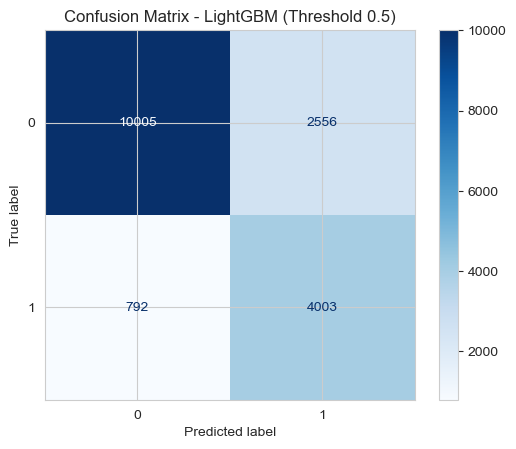

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve

y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_pred_default = (y_prob_test >= 0.5).astype(int)

print(f"=== {final_model_name} (tuned) - Threshold 0.5 - Test Set ===")
print(classification_report(y_test, y_pred_default, digits=3))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_test):.4f} | PR-AUC: {average_precision_score(y_test, y_prob_test):.4f}")

cm = confusion_matrix(y_test, y_pred_default)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {final_model_name} (Threshold 0.5)')
plt.show()

### 11.2 Precision-Recall Curve

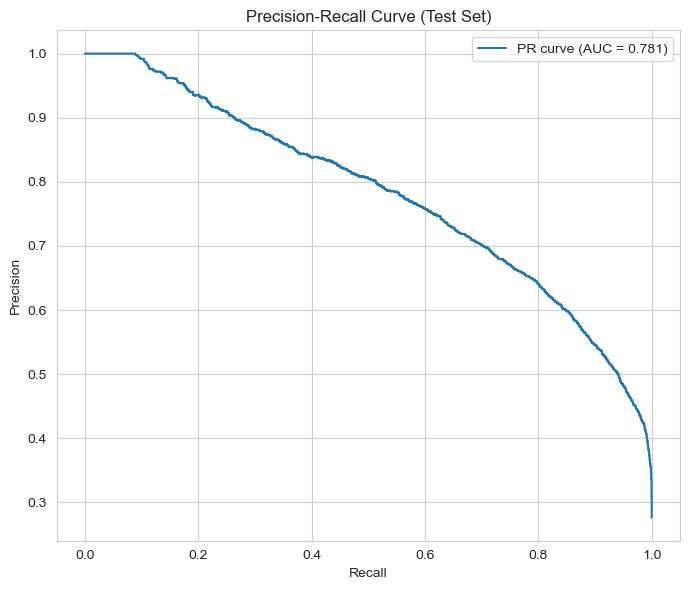

In [44]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_test)
pr_auc = average_precision_score(y_test, y_prob_test)

plt.figure(figsize=(7, 6))
plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Test Set)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 11.3 Threshold Optimal Berbasis Biaya Bisnis

**Asumsi biaya** (bisa dan sebaiknya dikalibrasi ulang dengan angka riil perusahaan sebelum dipakai operasional):
- Biaya retensi (follow-up/promo ke tamu yang ditandai berisiko) = **1 unit**
- Biaya kamar kosong akibat tamu batal tanpa antisipasi = **10 unit** (asumsi kehilangan tamu 10x lebih mahal daripada usaha retensi)

**Definisi:**
- **False Positive (FP)**: tamu yang tidak akan batal, tapi ditandai berisiko batal → biaya retensi terbuang (1 unit).
- **False Negative (FN)**: tamu yang benar-benar batal, tapi tidak terdeteksi → kamar kosong tak terantisipasi (10 unit).

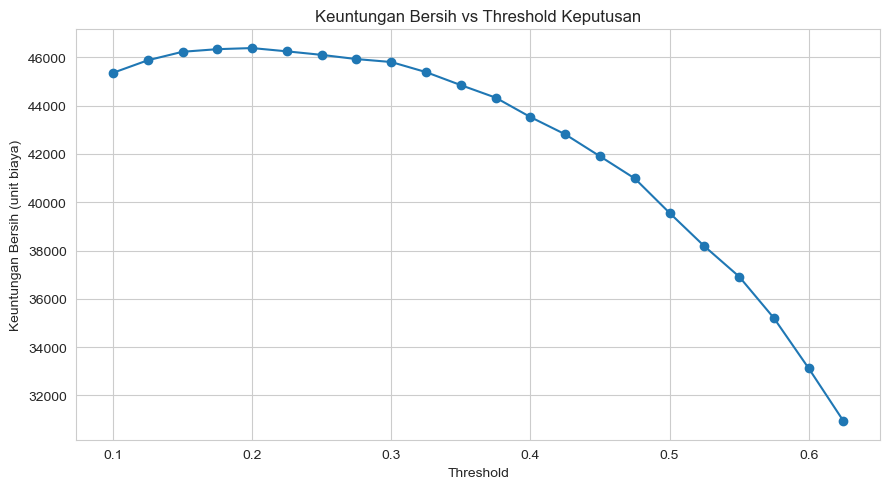

,Threshold,TN,FP,FN,TP,Total Kerugian,Total Keuntungan,Bersih
0,0.100,5354,7207,37,4758,7577,52934,45357
1,0.125,5734,6827,49,4746,7317,53194,45877
2,0.150,6060,6501,64,4731,7141,53370,46229
3,0.175,6404,6157,93,4702,7087,53424,46337
4,0.200,6727,5834,123,4672,7064,53447,46383
5,0.225,7049,5512,162,4633,7132,53379,46247
6,0.250,7386,5175,203,4592,7205,53306,46101
7,0.275,7689,4872,242,4553,7292,53219,45927
8,0.300,7988,4573,278,4517,7353,53158,45805
9,0.325,8279,4282,328,4467,7562,52949,45387


In [45]:
def hitung_biaya(y_true, y_pred, biaya_retensi=1, biaya_kamar_kosong=10):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_kerugian = fp * biaya_retensi + fn * biaya_kamar_kosong
    total_keuntungan = tn * biaya_retensi + tp * biaya_kamar_kosong
    return {"TN": tn, "FP": fp, "FN": fn, "TP": tp,
            "Total Kerugian": total_kerugian, "Total Keuntungan": total_keuntungan,
            "Bersih": total_keuntungan - total_kerugian}

hasil_threshold = []
for t in np.arange(0.10, 0.65, 0.025):
    y_pred_t = (y_prob_test >= t).astype(int)
    hasil = hitung_biaya(y_test, y_pred_t)
    hasil["Threshold"] = round(t, 3)
    hasil_threshold.append(hasil)

cost_df = pd.DataFrame(hasil_threshold)[["Threshold", "TN", "FP", "FN", "TP", "Total Kerugian", "Total Keuntungan", "Bersih"]]

plt.figure(figsize=(9,5))
plt.plot(cost_df['Threshold'], cost_df['Bersih'], marker='o')
plt.xlabel('Threshold')
plt.ylabel('Keuntungan Bersih (unit biaya)')
plt.title('Keuntungan Bersih vs Threshold Keputusan')
plt.grid(True)
plt.tight_layout()
plt.show()

cost_df

Threshold dengan keuntungan bersih tertinggi: 0.2
Threshold               0.2
TN                   6727.0
FP                   5834.0
FN                    123.0
TP                   4672.0
Total Kerugian       7064.0
Total Keuntungan    53447.0
Bersih              46383.0
Name: 4, dtype: float64

=== Classification Report dengan Threshold Optimal (0.2) ===
              precision    recall  f1-score   support

           0      0.982     0.536     0.693     12561
           1      0.445     0.974     0.611      4795

    accuracy                          0.657     17356
   macro avg      0.713     0.755     0.652     17356
weighted avg      0.834     0.657     0.670     17356



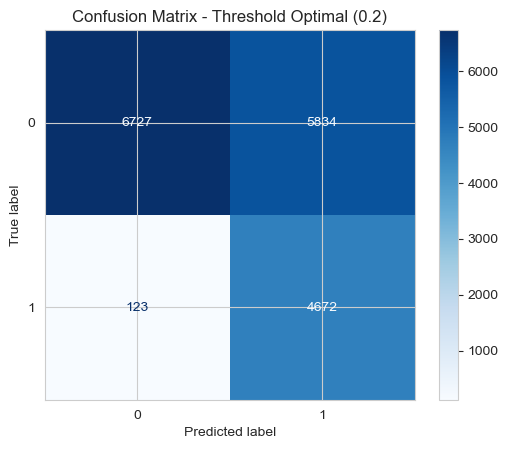

In [46]:
best_row = cost_df.loc[cost_df['Bersih'].idxmax()]
best_threshold = best_row['Threshold']
print(f"Threshold dengan keuntungan bersih tertinggi: {best_threshold}")
print(best_row)

y_pred_final = (y_prob_test >= best_threshold).astype(int)
print(f"\n=== Classification Report dengan Threshold Optimal ({best_threshold}) ===")
print(classification_report(y_test, y_pred_final, digits=3))

cm_final = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final)
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix - Threshold Optimal ({best_threshold})")
plt.show()

**Insight:** Karena biaya kamar kosong (FN) 10x lebih mahal daripada biaya retensi (FP), keuntungan bersih justru **lebih tinggi pada threshold yang jauh di bawah 0.5**, mengonfirmasi bahwa dalam konteks bisnis ini, lebih baik model "lebih waspada" (menandai lebih banyak tamu sebagai berisiko batal) daripada berusaha presisi sempurna. Ini adalah threshold yang akan dipakai pada model final, **bukan default 0.5**.

### 11.4 Feature Importance

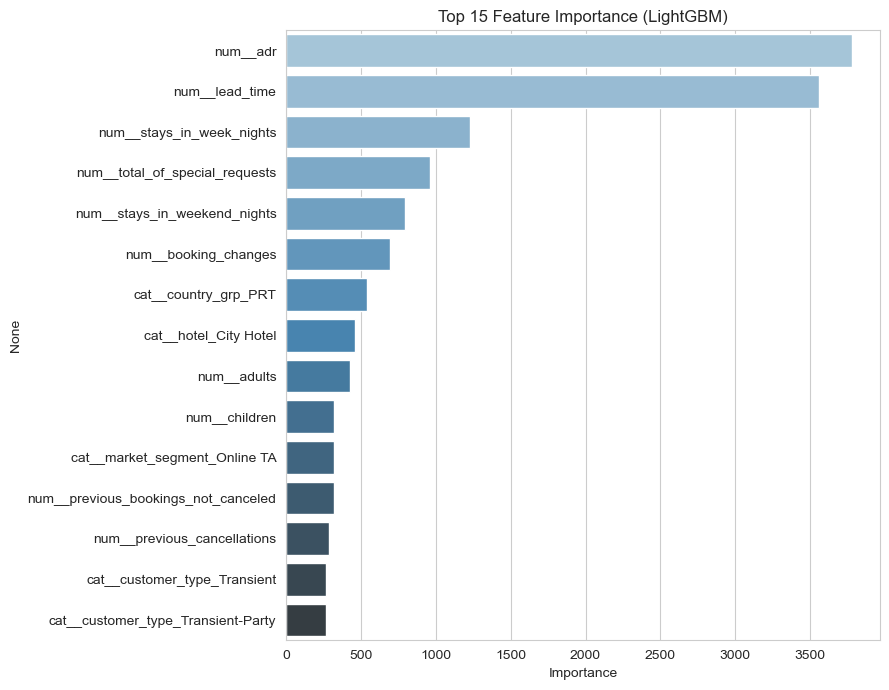

In [47]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['classifier'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=feat_imp.values, y=feat_imp.index, hue=feat_imp.index, legend=False, palette='Blues_d')
plt.title(f'Top 15 Feature Importance ({final_model_name})')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [48]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


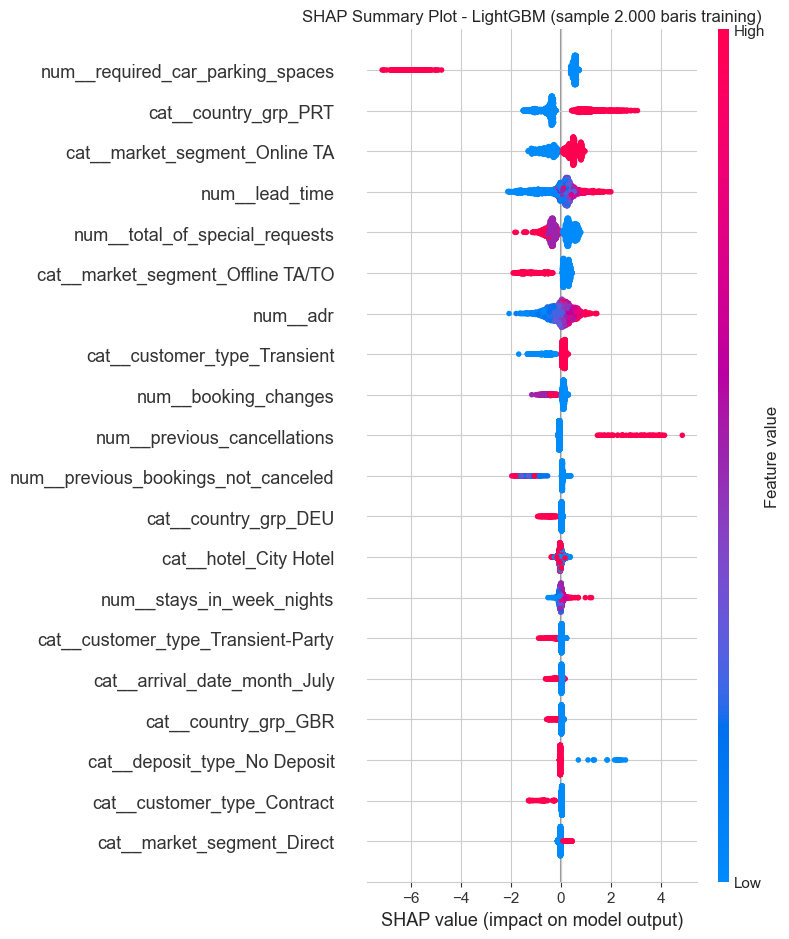

In [49]:
import shap

X_train_transformed = best_model.named_steps['preprocessor'].transform(X_train)

# Subsample untuk efisiensi komputasi SHAP pada dataset besar
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_train_transformed.shape[0], size=min(2000, X_train_transformed.shape[0]), replace=False)
X_sample = X_train_transformed[sample_idx]

explainer = shap.TreeExplainer(best_model.named_steps['classifier'])
shap_values = explainer.shap_values(X_sample)

# Beberapa versi library boosting mengembalikan list [kelas0, kelas1] atau array langsung
sv_plot = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv_plot, X_sample, feature_names=feature_names, show=False)
plt.title(f'SHAP Summary Plot - {final_model_name} (sample 2.000 baris training)')
plt.tight_layout()
plt.show()

**Insight Feature Importance (native + SHAP):**

- **`adr`** (harga kamar per malam) dan **`lead_time`** adalah dua fitur paling berpengaruh, konsisten dengan temuan korelasi di bagian 5.1 dan Pertanyaan EDA #1: booking dengan harga lebih tinggi dan lead time lebih panjang lebih berisiko batal.
- **`stays_in_week_nights`** dan **`total_of_special_requests`** juga cukup berpengaruh, tamu dengan permintaan khusus lebih jarang batal (konsisten dengan bagian 5.1 & 5.3).
- **`country_grp_PRT`** (Portugal) muncul sebagai fitur penting, konsisten dengan temuan multivariate di bagian 6.3 bahwa Portugal punya pola pembatalan yang unik.
- **`market_segment_Online TA`** juga masuk fitur penting, konsisten dengan Pertanyaan EDA #5.

Semua temuan model ini **konsisten dengan EDA** di bagian sebelumnya, tanda baik bahwa model belajar pola yang masuk akal secara bisnis, bukan noise.

### 11.5 Perbandingan Biaya: Dengan Model vs Tanpa Model

Membandingkan strategi menggunakan model (threshold optimal) dengan dua skenario naif: menganggap **semua booking tidak akan batal**, atau menganggap **semua booking akan batal** (setara *full overbooking*).

In [50]:
n_test = len(y_test)

skenario_semua_tidak_batal = hitung_biaya(y_test, np.zeros(n_test, dtype=int))
skenario_semua_batal = hitung_biaya(y_test, np.ones(n_test, dtype=int))
skenario_model = hitung_biaya(y_test, y_pred_final)

comparison = pd.DataFrame([
    {'Strategi': 'Tanpa model - anggap semua TIDAK batal', **skenario_semua_tidak_batal},
    {'Strategi': 'Tanpa model - anggap semua BATAL (full overbooking)', **skenario_semua_batal},
    {'Strategi': f'Dengan Model ({final_model_name}, threshold={best_threshold})', **skenario_model},
])[['Strategi', 'TN', 'FP', 'FN', 'TP', 'Total Kerugian', 'Total Keuntungan', 'Bersih']]

comparison

,Strategi,TN,FP,FN,TP,Total Kerugian,Total Keuntungan,Bersih
0,Tanpa model - anggap semua TIDAK batal,12561,0,4795,0,47950,12561,-35389
1,Tanpa model - anggap semua BATAL (full overbooking),0,12561,0,4795,12561,47950,35389
2,"Dengan Model (LightGBM, threshold=0.2)",6727,5834,123,4672,7064,53447,46383


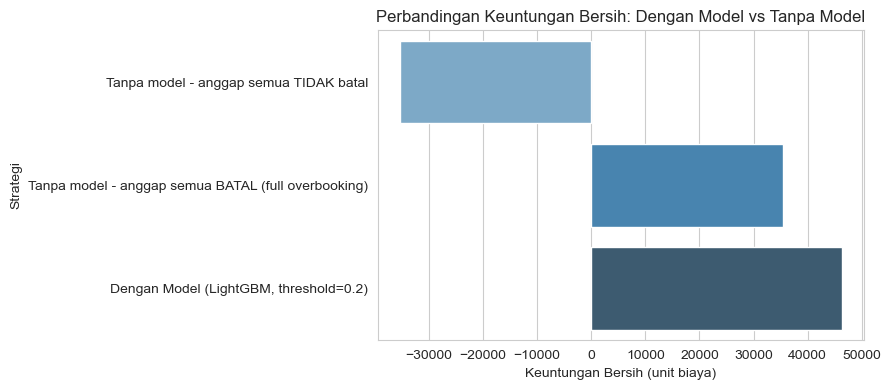

In [51]:
plt.figure(figsize=(9,4))
sns.barplot(data=comparison, x='Bersih', y='Strategi', hue='Strategi', legend=False, palette='Blues_d')
plt.title('Perbandingan Keuntungan Bersih: Dengan Model vs Tanpa Model')
plt.xlabel('Keuntungan Bersih (unit biaya)')
plt.tight_layout()
plt.show()

**Insight:** Strategi dengan model (threshold optimal) menghasilkan keuntungan bersih **lebih tinggi** dibanding kedua skenario naif, termasuk dibanding strategi "anggap semua batal" (setara kebijakan *full overbooking* buta tanpa data), yang selama ini mungkin menjadi pendekatan implisit perusahaan untuk mengantisipasi kamar kosong. Model memungkinkan perusahaan **menargetkan mitigasi hanya pada booking yang benar-benar berisiko**, bukan memperlakukan semua booking sama.

## 12. Simpan Model Final & Fungsi Deteksi Booking Berisiko

Model, threshold, dan daftar kolom fitur disimpan bersamaan agar mudah dipakai ulang untuk deployment (misalnya untuk aplikasi Streamlit yang direncanakan selanjutnya).

In [52]:
import pickle as pkl

final_artifact = {
    "model": best_model,
    "threshold": float(best_threshold),
    "feature_columns": X.columns.tolist(),
    "cat_cols": cat_cols,
    "num_cols": num_cols,
    "top_countries": top_countries,
    "model_name": final_model_name,
}

with open("final_model_hotel_cancellation.pkl", "wb") as f:
    pkl.dump(final_artifact, f)

print("Model, threshold, dan daftar kolom fitur berhasil disimpan ke 'final_model_hotel_cancellation.pkl'")

Model, threshold, dan daftar kolom fitur berhasil disimpan ke 'final_model_hotel_cancellation.pkl'


### 12.1 Fungsi Deteksi Booking Berpotensi Batal

Fungsi ini mensimulasikan bagaimana perusahaan bisa memakai model untuk **mendeteksi booking berisiko batal sejak awal proses booking**, data baru harus punya kolom yang sama seperti `feature_columns` (tanpa `is_canceled`, dan tanpa kolom yang sudah dibuang saat cleaning: `reservation_status`, `reservation_status_date`, `assigned_room_type`, `agent`, `company`, `arrival_date_year`, `arrival_date_week_number`, `arrival_date_day_of_month`).

Fungsi ini juga menjadi fondasi untuk endpoint prediksi di aplikasi Streamlit yang direncanakan selanjutnya.

In [53]:
def prediksi_risiko_cancel(df_booking_baru, artifact=final_artifact):
    '''
    Memprediksi probabilitas & label risiko pembatalan untuk booking baru.

    Parameters
    ----------
    df_booking_baru : pd.DataFrame
        Data booking baru dengan kolom yang sama seperti data training
        (sebelum di-drop kolom leakage/id), termasuk kolom 'country' mentah.
    artifact : dict
        Dictionary hasil pickle.load() dari 'final_model_hotel_cancellation.pkl'.

    Returns
    -------
    pd.DataFrame dengan kolom tambahan 'prob_cancel' dan 'prediksi_risiko'.
    '''
    data = df_booking_baru.copy()

    # Terapkan grouping country yang sama seperti saat training
    top_countries_ = artifact['top_countries']
    if 'country' in data.columns:
        data['country_grp'] = data['country'].apply(lambda x: x if x in top_countries_ else 'Other')
        data = data.drop(columns=['country'])

    # Pastikan urutan & kelengkapan kolom sesuai feature_columns
    missing_cols = set(artifact['feature_columns']) - set(data.columns)
    if missing_cols:
        raise ValueError(f"Kolom berikut belum ada di data baru: {missing_cols}")
    data = data[artifact['feature_columns']]

    model = artifact['model']
    threshold = artifact['threshold']

    prob = model.predict_proba(data)[:, 1]
    label = (prob >= threshold).astype(int)

    hasil = df_booking_baru.copy()
    hasil['prob_cancel'] = prob
    hasil['prediksi_risiko'] = np.where(label == 1, 'Berisiko Batal', 'Kemungkinan Datang')
    return hasil


# Contoh pemakaian: ambil 5 baris dari test set (kolom asli sebelum split X/y) sebagai simulasi "booking baru"
contoh_booking_baru = df.loc[X_test.index, X.columns.tolist() + []].copy()
# tambahkan kembali kolom 'country' asli untuk contoh ini (karena sudah diganti country_grp di df_model)
contoh_booking_baru['country'] = df.loc[X_test.index, 'country_grp'] if 'country_grp' in df.columns else None
contoh_booking_baru = contoh_booking_baru.drop(columns=['country_grp'], errors='ignore').head(5)

hasil_contoh = prediksi_risiko_cancel(contoh_booking_baru)
hasil_contoh[['lead_time', 'adr', 'market_segment', 'deposit_type', 'prob_cancel', 'prediksi_risiko']]

,lead_time,adr,market_segment,deposit_type,prob_cancel,prediksi_risiko
73454,7,90.10,Online TA,No Deposit,0.129549,Kemungkinan Datang
9412,186,238.71,Online TA,No Deposit,0.947748,Berisiko Batal
27619,119,69.00,Online TA,No Deposit,0.001425,Kemungkinan Datang
44650,168,205.00,Online TA,No Deposit,0.957035,Berisiko Batal
60526,169,63.50,Offline TA/TO,No Deposit,0.001408,Kemungkinan Datang


**Catatan:** Contoh di atas memakai ulang data test hanya untuk mendemonstrasikan format input/output fungsi. Untuk pemakaian produksi (mis. saat integrasi dengan sistem booking/PMS atau aplikasi Streamlit), `df_booking_baru` akan berisi data booking baru yang benar-benar belum diketahui hasil akhirnya.

## 13. Kesimpulan & Rekomendasi Bisnis

### Kesimpulan

- Cancellation rate pada data mentah (~37%) konsisten dengan angka masalah bisnis yang dilaporkan. Setelah cleaning (terutama pembuangan duplikat), rate turun ke ~27-28%. **Gap ini perlu divalidasi lebih lanjut di internal perusahaan**.
- EDA univariate, bivariate, dan multivariate mengonfirmasi bahwa **tidak ada satu fitur pun yang berkorelasi linear sangat kuat** dengan pembatalan (VIF juga menunjukkan tidak ada multikolinearitas), pola pembatalan lebih banyak terbentuk dari **kombinasi/interaksi fitur** (mis. Non Refund x Portugal x TA/TO), sehingga model *tree-based*/boosting yang bisa menangkap interaksi non-linear jauh lebih sesuai dibanding model linear sederhana.
- Dari 8 model yang dibandingkan (benchmarking), 3 model boosting modern (**CatBoost, XGBoost, LightGBM**) konsisten unggul. Setelah *hyperparameter tuning* (dengan scorer PR-AUC, bukan skor pada threshold tetap) dan *cross-validation* 5-fold, model dengan PR-AUC dan ROC-AUC tertinggi secara konsisten terpilih sebagai **model final** (lihat hasil aktual pada bagian 10.3 di atas).
- Dengan *threshold* yang dioptimalkan berdasarkan biaya bisnis (bukan default 0.5), model final menghasilkan **keuntungan bersih yang lebih tinggi** dibanding strategi naif "anggap semua batal" (full overbooking) maupun "anggap semua tidak batal".
- Fitur paling berpengaruh terhadap pembatalan: **`adr`**, **`lead_time`**, **`stays_in_week_nights`**, **`total_of_special_requests`**, **`country_grp_PRT`**, dan **`market_segment_Online TA`** dan seluruhnya konsisten dengan temuan EDA.

### Rekomendasi untuk Mengurangi Kamar Kosong

1. **Kebijakan berbasis lead time**: terapkan konfirmasi ulang otomatis (WA/telepon/email) untuk booking dengan lead time panjang, karena risiko batalnya jauh lebih tinggi (Pertanyaan EDA #1).
2. **Prioritaskan mitigasi di channel Online TA** dan segmen **Groups**, karena kombinasi *rate* dan *volume* pembatalannya paling tinggi (Pertanyaan EDA #5).
3. **Audit skema deposit Non Refund di Portugal**: temuan cancellation rate ~94,7% pada `Non Refund` sangat tidak wajar dan terkonsentrasi pada satu negara/channel.
4. **Overbooking musiman terukur**: gunakan estimasi probabilitas pembatalan dari model (`prob_cancel`) untuk menghitung *expected cancellations* per periode (terutama peak season April-Agustus), sebagai dasar kuota *controlled overbooking*.
5. **Gunakan `prediksi_risiko_cancel()` di awal proses booking** untuk menandai booking berisiko tinggi secara real-time, lalu arahkan ke alur retensi (follow-up, insentif kecil, atau konfirmasi kehadiran) sebelum kamar benar-benar hilang dari inventori yang bisa dijual ulang.
